# Enron (Class: Benign) - 25,825
https://www.kaggle.com/datasets/wcukierski/enron-email-dataset

In [1]:
import kagglehub

# Download latest version
enronRoot = kagglehub.dataset_download("wcukierski/enron-email-dataset")

print("Path to dataset files:", enronRoot)

Path to dataset files: C:\Users\karth\.cache\kagglehub\datasets\wcukierski\enron-email-dataset\versions\2


In [2]:
import pandas as pd
enronFilePath = enronRoot+'/emails.csv'
dfEnron2 = pd.read_csv(enronFilePath)

dfEnron2

,file,message
0,allen-p/_sent_mail/1.,Message-ID: <18782981.1075855378110.JavaMail.e...
1,allen-p/_sent_mail/10.,Message-ID: <15464986.1075855378456.JavaMail.e...
2,allen-p/_sent_mail/100.,Message-ID: <24216240.1075855687451.JavaMail.e...
3,allen-p/_sent_mail/1000.,Message-ID: <13505866.1075863688222.JavaMail.e...
4,allen-p/_sent_mail/1001.,Message-ID: <30922949.1075863688243.JavaMail.e...
...,...,...
517396,zufferli-j/sent_items/95.,Message-ID: <26807948.1075842029936.JavaMail.e...
517397,zufferli-j/sent_items/96.,Message-ID: <25835861.1075842029959.JavaMail.e...
517398,zufferli-j/sent_items/97.,Message-ID: <28979867.1075842029988.JavaMail.e...
517399,zufferli-j/sent_items/98.,Message-ID: <22052556.1075842030013.JavaMail.e...


In [3]:
import pandas as pd
enronSliced = dfEnron2[0:50000]
enronSliced

,file,message
0,allen-p/_sent_mail/1.,Message-ID: <18782981.1075855378110.JavaMail.e...
1,allen-p/_sent_mail/10.,Message-ID: <15464986.1075855378456.JavaMail.e...
2,allen-p/_sent_mail/100.,Message-ID: <24216240.1075855687451.JavaMail.e...
3,allen-p/_sent_mail/1000.,Message-ID: <13505866.1075863688222.JavaMail.e...
4,allen-p/_sent_mail/1001.,Message-ID: <30922949.1075863688243.JavaMail.e...
...,...,...
49995,cash-m/sent_items/346.,Message-ID: <1815718.1075855358574.JavaMail.ev...
49996,cash-m/sent_items/347.,Message-ID: <15801367.1075855358596.JavaMail.e...
49997,cash-m/sent_items/348.,Message-ID: <23815150.1075855358619.JavaMail.e...
49998,cash-m/sent_items/349.,Message-ID: <23974470.1075855358641.JavaMail.e...


In [4]:
import re
def parse_email(raw_email: str):
    lines = raw_email.splitlines()
    
    from_value = ""
    subject_value = ""
    date_value = None
    body_lines = []
    in_body = False
    
    for line in lines:
        # Detect start of body (blank line after headers)
        if not in_body and line.strip() == "":
            in_body = True
            continue
        
        if in_body:
            body_lines.append(line)
        else:
            if line.lower().startswith("from:"):
                from_value = line[len("From:"):].strip()
            elif line.lower().startswith("subject:"):
                subject_value = line[len("Subject:"):].strip()
            elif line.lower().startswith("date:"):
                date_value = pd.to_datetime(line[len("Date:"):].strip()).replace(tzinfo=None)
    
    body_value = "\n".join(body_lines).strip()
    
    links = re.findall(r'(https?://\S+)', body_value)
    
    # Enron dataset contains no attachment information so empty list
    attachments = []
    
    return pd.Series([date_value, from_value, subject_value, body_value, links, attachments])

In [5]:
enronDf = enronSliced['message'].apply(parse_email)
enronDf.columns = ['Date', 'From', 'Subject', 'Body', 'Links', 'Attachments']
enronDf["Classification"] = "Benign"
enronDf["provenance_tag"] = "Enron Email Dataset"
enronDf = enronDf.drop_duplicates(subset="Body")
enronDf
#print(type(enronDf['Date'][0]))
#print(pd.to_datetime(enronDf['Date'][0]))

#enronDf.to_csv("Enron500k.csv", index=False)

,Date,From,Subject,Body,Links,Attachments,Classification,provenance_tag
0,2001-05-14 16:39:00,phillip.allen@enron.com,,Here is our forecast,[],[],Benign,Enron Email Dataset
1,2001-05-04 13:51:00,phillip.allen@enron.com,Re:,Traveling to have a business meeting takes the...,[],[],Benign,Enron Email Dataset
2,2000-10-18 03:00:00,phillip.allen@enron.com,Re: test,test successful. way to go!!!,[],[],Benign,Enron Email Dataset
3,2000-10-23 06:13:00,phillip.allen@enron.com,,"Randy,\n\n Can you send me a schedule of the s...",[],[],Benign,Enron Email Dataset
4,2000-08-31 05:07:00,phillip.allen@enron.com,Re: Hello,Let's shoot for Tuesday at 11:45.,[],[],Benign,Enron Email Dataset
...,...,...,...,...,...,...,...,...
49995,2001-12-09 10:01:28,michelle.cash@enron.com,FW: Pam Benson,"please file ""Pam Benson"". Thanks. MHC\n\n --...",[],[],Benign,Enron Email Dataset
49996,2001-12-09 10:03:50,michelle.cash@enron.com,FW: ECI,please file in Diomedes' file. Thanks. MHC\n...,[],[],Benign,Enron Email Dataset
49997,2001-12-09 12:01:38,michelle.cash@enron.com,RE: In re Event Resources,fine with me. mhc\n\n-----Original Message---...,[],[],Benign,Enron Email Dataset
49998,2001-12-09 12:24:13,michelle.cash@enron.com,RE: List of People,You need more than the 840 for this -- you als...,[],[],Benign,Enron Email Dataset


# Enron Filtered (Class: Benign) - 15,794
https://www.kaggle.com/datasets/marcelwiechmann/enron-spam-data/data?select=enron_spam_data.csv

In [6]:
# Enron Filtered Dataset
import pandas as pd

enronFilePath = './enron_spam_data.csv'
dfEnron = pd.read_csv(enronFilePath)

dfEnron

,Unnamed: 0,Subject,Message,Spam/Ham,Date
0,0,christmas tree farm pictures,NaN,ham,1999-12-10
1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13
2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14
3,3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14
4,4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14
...,...,...,...,...,...
33711,33711,fw : re ivanhoe e . s . d,"fyi , kim .\n- - - - - original message - - - ...",spam,2005-07-29
33712,33712,fw : re ivanhoe e . s . d,"fyi , kim .\n- - - - - original message - - - ...",spam,2005-07-29
33713,33713,fw : re ivanhoe e . s . d,"fyi , kim .\n- - - - - original message - - - ...",spam,2005-07-30
33714,33714,fw : re ivanhoe e . s . d,"fyi , kim .\n- - - - - original message - - - ...",spam,2005-07-30


In [7]:
# Isolate Enron Ham Entries

indicesToDrop = dfEnron[dfEnron['Spam/Ham']=='spam'].index

dfEnronHam = dfEnron.drop(indicesToDrop, inplace=False)
dfEnronHam = dfEnronHam.drop_duplicates(subset="Message")
dfEnronHam
#print(pd.to_datetime(dfEnronHam['Date'][0]))

,Unnamed: 0,Subject,Message,Spam/Ham,Date
0,0,christmas tree farm pictures,NaN,ham,1999-12-10
1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13
2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14
3,3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14
4,4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14
...,...,...,...,...,...
29211,29211,tw weekend scheduled volumes,march 2002 scheduled\nscheduled\nfriday 22\nwe...,ham,2002-03-25
29212,29212,fw : re ivanhoe e . s . d,"fyi , kim .\n- - - - - original message - - - ...",ham,2002-03-25
29213,29213,fw : abandoned pipe ownership,"fyi , kim .\n- - - - - original message - - - ...",ham,2002-03-25
29214,29214,fw : tw question in amarillo,"fyi , kim .\n- - - - - original message - - - ...",ham,2002-03-25


In [8]:
import re
def parse_email(date, subject, body):

    #no sender info in Ling or Enron Filtered
    sender = ""

    # Extract Links from body
    links = re.findall(r"https?://\S+", body, re.IGNORECASE)

    # Extract Attachments
    attachments = []

    return pd.Series([pd.to_datetime(date).replace(tzinfo=None), sender, subject, body, links, attachments])

#ling and enron ham seems to have no links
dfEnronHam[['Date', 'Subject', 'Message']] = dfEnronHam[['Date', 'Subject', 'Message']].fillna('')
enronDf2 = dfEnronHam.apply(lambda row: parse_email(row['Date'], row['Subject'], row['Message']), axis=1)
enronDf2.columns = ['Date', 'From', 'Subject', 'Body', 'Links', 'Attachments']
enronDf2["Classification"] = "Benign"
enronDf2["provenance_tag"] = "Enron Filtered Dataset"
enronDf2

#enronDf2.to_csv("Enron_Filtered.csv", index=False)


,Date,From,Subject,Body,Links,Attachments,Classification,provenance_tag
0,1999-12-10,,christmas tree farm pictures,,[],[],Benign,Enron Filtered Dataset
1,1999-12-13,,"vastar resources , inc .","gary , production from the high island larger ...",[],[],Benign,Enron Filtered Dataset
2,1999-12-14,,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,[],[],Benign,Enron Filtered Dataset
3,1999-12-14,,re : issue,fyi - see note below - already done .\nstella\...,[],[],Benign,Enron Filtered Dataset
4,1999-12-14,,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,[],[],Benign,Enron Filtered Dataset
...,...,...,...,...,...,...,...,...
29211,2002-03-25,,tw weekend scheduled volumes,march 2002 scheduled\nscheduled\nfriday 22\nwe...,[],[],Benign,Enron Filtered Dataset
29212,2002-03-25,,fw : re ivanhoe e . s . d,"fyi , kim .\n- - - - - original message - - - ...",[],[],Benign,Enron Filtered Dataset
29213,2002-03-25,,fw : abandoned pipe ownership,"fyi , kim .\n- - - - - original message - - - ...",[],[],Benign,Enron Filtered Dataset
29214,2002-03-25,,fw : tw question in amarillo,"fyi , kim .\n- - - - - original message - - - ...",[],[],Benign,Enron Filtered Dataset


# Enron Filtered (Class: Spam) - 6
https://www.kaggle.com/datasets/marcelwiechmann/enron-spam-data

In [9]:
# Isolate Enron Spam Entries

indicesToDrop = dfEnron[dfEnron['Spam/Ham']=='ham'].index

dfEnronSpam = dfEnron.drop(indicesToDrop, inplace=False)
dfEnronSpam = dfEnronSpam.drop_duplicates(subset="Message")
len(dfEnronSpam)

6

In [10]:
dfEnronSpam[['Date', 'Subject', 'Message']] = dfEnronSpam[['Date', 'Subject', 'Message']].fillna('')
enronSpamDf = dfEnronSpam.apply(lambda row: parse_email(row['Date'], row['Subject'], row['Message']), axis=1)
enronSpamDf.columns = ['Date', 'From', 'Subject', 'Body', 'Links', 'Attachments']
enronSpamDf["Classification"] = "Spam"
enronSpamDf["provenance_tag"] = "Enron Spam Dataset"
enronSpamDf

#enronSpamDf.to_csv("Enron_Spam.csv", index=False)

,Date,From,Subject,Body,Links,Attachments,Classification,provenance_tag
3672,2003-12-18,,re : tenaska iv,i tried calling you this am but your phone rol...,[],[],Spam,Enron Spam Dataset
9533,2001-05-25,,fw : memo : re : your work phone number,"hi ,\ni am forwarding an email from a former b...",[],[],Spam,Enron Spam Dataset
15041,2004-08-01,,re : releases,"louise ,\nthanks so much for your speedy reply...",[],[],Spam,Enron Spam Dataset
18041,2003-12-18,,start date : 2 / 6 / 02 ; hourahead hour : 24 ;,start date : 2 / 6 / 02 ; hourahead hour : 24 ...,[],[],Spam,Enron Spam Dataset
24041,2001-05-25,,transfers from ees,attached is the latest version of the cost cen...,[],[],Spam,Enron Spam Dataset
29216,2004-08-01,,fw : re ivanhoe e . s . d,"fyi , kim .\n- - - - - original message - - - ...",[],[],Spam,Enron Spam Dataset


# Spam Assassin 2 (Class: Spam) - 1718
https://www.kaggle.com/datasets/naserabdullahalam/phishing-email-dataset?select=SpamAssasin.csv

In [11]:
# Dataset Containing Enron, NigerianFraud, SpamAssassin, Nazario, Ling datasets

import kagglehub

# Download latest version
spamAssassin2Root = kagglehub.dataset_download("naserabdullahalam/phishing-email-dataset")

print("Path to dataset files:", spamAssassin2Root)

Path to dataset files: C:\Users\karth\.cache\kagglehub\datasets\naserabdullahalam\phishing-email-dataset\versions\1


In [12]:
import pandas as pd
spamAssassin2FilePath = spamAssassin2Root+'/SpamAssasin.csv'
dfSpamAssassin2 = pd.read_csv(spamAssassin2FilePath)

dfSpamAssassin2

,sender,receiver,date,subject,body,label,urls
0,Robert Elz <kre@munnari.OZ.AU>,Chris Garrigues <cwg-dated-1030377287.06fa6d@D...,"Thu, 22 Aug 2002 18:26:25 +0700",Re: New Sequences Window,"Date: Wed, 21 Aug 2002 10:54:46 -0500 ...",0,1
1,Steve Burt <Steve_Burt@cursor-system.com>,"""'zzzzteana@yahoogroups.com'"" <zzzzteana@yahoo...","Thu, 22 Aug 2002 12:46:18 +0100",[zzzzteana] RE: Alexander,"Martin A posted:\nTassos Papadopoulos, the Gre...",0,1
2,"""Tim Chapman"" <timc@2ubh.com>",zzzzteana <zzzzteana@yahoogroups.com>,"Thu, 22 Aug 2002 13:52:38 +0100",[zzzzteana] Moscow bomber,Man Threatens Explosion In Moscow \n\nThursday...,0,1
3,Monty Solomon <monty@roscom.com>,undisclosed-recipient: ;,"Thu, 22 Aug 2002 09:15:25 -0400",[IRR] Klez: The Virus That Won't Die,Klez: The Virus That Won't Die\n \nAlready the...,0,1
4,Stewart Smith <Stewart.Smith@ee.ed.ac.uk>,zzzzteana@yahoogroups.com,"Thu, 22 Aug 2002 14:38:22 +0100",Re: [zzzzteana] Nothing like mama used to make,"> in adding cream to spaghetti carbonara, whi...",0,1
...,...,...,...,...,...,...,...
5804,Professional_Career_Development_Institute@Frug...,yyyy@netnoteinc.com,"Tue, 3 Dec 2002 13:19:58 -0800",Busy? Home Study Makes Sense!,\n\n \n--- \n![](http://images.pcdi-homestud...,1,1
5805,"""IQ - TBA"" <tba@insiq.us>",<yyyy@spamassassin.taint.org>,"Tue, 3 Dec 2002 18:52:29 -0500",Preferred Non-Smoker Rates for Smokers,This is a multi-part message in MIME format. -...,1,1
5806,Mike <raye@yahoo.lv>,Mailing.List@user2.pro-ns.net,"Sun, 20 Jul 2003 16:19:44 +0800","How to get 10,000 FREE hits per day to any web...","Dear Subscriber,\n\nIf I could show you a way ...",1,1
5807,"""Mr. Clean"" <cweqx@dialix.oz.au>",<Undisclosed.Recipients@webnote.net>,"Wed, 05 Aug 2020 04:01:50 -1900",Cannabis Difference,****Mid-Summer Customer Appreciation SALE!****...,1,0


In [13]:
# Drop SpamAssassin Ham entries
indicesToDrop = dfSpamAssassin2[dfSpamAssassin2['label']==0].index
dfSpamAssassinSpam2 = dfSpamAssassin2.drop(indicesToDrop, inplace=False)
dfSpamAssassinSpam2 = dfSpamAssassinSpam2.drop_duplicates(subset="body")

dfSpamAssassinSpam2
#print(pd.to_datetime(dfSpamAssassinSpam2['date'][4091]))

,sender,receiver,date,subject,body,label,urls
4091,12a1mailbot1@web.de,<dcek1a1@netsgo.com>,"Wed, 21 Aug 2002 20:31:57 -1600",Life Insurance - Why Pay More?,* * * --- * * * <= /TR> Save...,1,1
4092,"""Slim Down"" <taylor@s3.serveimage.com>",<ilug@linux.ie>,"Thu, 22 Aug 2002 06:18:18 -0600",[ILUG] Guaranteed to lose 10-12 lbs in 30 days...,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1,1
4093,"""Slim Down"" <sabrina@mx3.1premio.com>",<zzzz@spamassassin.taint.org>,"Thu, 22 Aug 2002 07:36:19 -0600",Guaranteed to lose 10-12 lbs in 30 days ...,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1,1
4094,Account Services <wsup@playful.com>,zzzz@spamassassin.taint.org,"Thu, 22 Aug 2002 08:13:35 -0700",Re: Fw: User Name & Password to Membership To ...,##############################################...,1,1
4095,"""Slim n Trim"" <yenene@mx2.1premio.com>",<social@linux.ie>,"Thu, 22 Aug 2002 09:33:07 -0600",[ILUG-Social] re: Guaranteed to lose 10-12 lbs...,I thought you might like these:\n1) Slim Down ...,1,1
...,...,...,...,...,...,...,...
5804,Professional_Career_Development_Institute@Frug...,yyyy@netnoteinc.com,"Tue, 3 Dec 2002 13:19:58 -0800",Busy? Home Study Makes Sense!,\n\n \n--- \n![](http://images.pcdi-homestud...,1,1
5805,"""IQ - TBA"" <tba@insiq.us>",<yyyy@spamassassin.taint.org>,"Tue, 3 Dec 2002 18:52:29 -0500",Preferred Non-Smoker Rates for Smokers,This is a multi-part message in MIME format. -...,1,1
5806,Mike <raye@yahoo.lv>,Mailing.List@user2.pro-ns.net,"Sun, 20 Jul 2003 16:19:44 +0800","How to get 10,000 FREE hits per day to any web...","Dear Subscriber,\n\nIf I could show you a way ...",1,1
5807,"""Mr. Clean"" <cweqx@dialix.oz.au>",<Undisclosed.Recipients@webnote.net>,"Wed, 05 Aug 2020 04:01:50 -1900",Cannabis Difference,****Mid-Summer Customer Appreciation SALE!****...,1,0


SpamAssassain2 Processing 

In [14]:
import re
def parse_email(date, sender, subject, body):

    # Extract Links from body
    links = re.findall(r"https?://\S+", body, re.IGNORECASE)

    # This dataset doesnt contain attachment information
    attachments = []
    
    return pd.Series([pd.to_datetime(date, errors='coerce').replace(tzinfo=None), sender, subject, body, links, attachments])

dfSpamAssassinSpam2[['date', 'sender', 'subject', 'body']] = dfSpamAssassinSpam2[['date', 'sender', 'subject', 'body']].fillna('')
spamAssassinDf2 = dfSpamAssassinSpam2.apply(lambda row: parse_email(row['date'], row['sender'], row['subject'], row['body']), axis=1)
spamAssassinDf2.columns = ['Date', 'From', 'Subject', 'Body', 'Links', 'Attachments']
spamAssassinDf2["Classification"] = "Spam"
spamAssassinDf2["provenance_tag"] = "SpamAssassin2 Dataset"
spamAssassinDf2

#spamAssassinDf2.to_csv("SpamAssassin2.csv", index=False)

C:\Users\karth\AppData\Local\Temp\ipykernel_29444\3565267215.py:10: FutureWarning: Parsed string "2002/09/14 Sat 02:29:32 CDT" included an un-recognized timezone "CDT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  return pd.Series([pd.to_datetime(date, errors='coerce').replace(tzinfo=None), sender, subject, body, links, attachments])
C:\Users\karth\AppData\Local\Temp\ipykernel_29444\3565267215.py:10: FutureWarning: Parsed string "Tue, 17 Sep 2002 09:15:32 PST" included an un-recognized timezone "PST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  return pd.Series([pd.to_datetime(date, errors='coerce').replace(tzinfo=None), sender, subject, body, links, attachments])
C:\Users\karth\AppData\Local\Temp\

,Date,From,Subject,Body,Links,Attachments,Classification,provenance_tag
4091,2002-08-21 20:31:57,12a1mailbot1@web.de,Life Insurance - Why Pay More?,* * * --- * * * <= /TR> Save...,[],[],Spam,SpamAssassin2 Dataset
4092,2002-08-22 06:18:18,"""Slim Down"" <taylor@s3.serveimage.com>",[ILUG] Guaranteed to lose 10-12 lbs in 30 days...,1) Fight The Risk of Cancer!\nhttp://www.adcli...,"[http://www.adclick.ws/p.cfm?o=315&s=pk007, ht...",[],Spam,SpamAssassin2 Dataset
4093,2002-08-22 07:36:19,"""Slim Down"" <sabrina@mx3.1premio.com>",Guaranteed to lose 10-12 lbs in 30 days ...,1) Fight The Risk of Cancer!\nhttp://www.adcli...,"[http://www.adclick.ws/p.cfm?o=315&s=pk007, ht...",[],Spam,SpamAssassin2 Dataset
4094,2002-08-22 08:13:35,Account Services <wsup@playful.com>,Re: Fw: User Name & Password to Membership To ...,##############################################...,"[http://80.71.66.8/farm/?aid=760382, http://80...",[],Spam,SpamAssassin2 Dataset
4095,2002-08-22 09:33:07,"""Slim n Trim"" <yenene@mx2.1premio.com>",[ILUG-Social] re: Guaranteed to lose 10-12 lbs...,I thought you might like these:\n1) Slim Down ...,[http://www.freeyankee.com/cgi/fy2/to.cgi?l=82...,[],Spam,SpamAssassin2 Dataset
...,...,...,...,...,...,...,...,...
5804,2002-12-03 13:19:58,Professional_Career_Development_Institute@Frug...,Busy? Home Study Makes Sense!,\n\n \n--- \n![](http://images.pcdi-homestud...,[http://images.pcdi-homestudy.com/ads/e277/uni...,[],Spam,SpamAssassin2 Dataset
5805,2002-12-03 18:52:29,"""IQ - TBA"" <tba@insiq.us>",Preferred Non-Smoker Rates for Smokers,This is a multi-part message in MIME format. -...,"[http://www.insuranceiq.com/optout/, http://ww...",[],Spam,SpamAssassin2 Dataset
5806,2003-07-20 16:19:44,Mike <raye@yahoo.lv>,"How to get 10,000 FREE hits per day to any web...","Dear Subscriber,\n\nIf I could show you a way ...",[http://www.worldbizservices.net/your/mpam/mor...,[],Spam,SpamAssassin2 Dataset
5807,2020-08-05 04:01:50,"""Mr. Clean"" <cweqx@dialix.oz.au>",Cannabis Difference,****Mid-Summer Customer Appreciation SALE!****...,[],[],Spam,SpamAssassin2 Dataset


# Nazario (Class: Credential Harvesting) - 1565
https://www.kaggle.com/datasets/naserabdullahalam/phishing-email-dataset?select=Nazario.csv

In [15]:
# Dataset Containing Enron, NigerianFraud, SpamAssassin, Nazario, Ling datasets

import kagglehub

# Download latest version
nazarioRoot = kagglehub.dataset_download("naserabdullahalam/phishing-email-dataset")

print("Path to dataset files:", nazarioRoot)

Path to dataset files: C:\Users\karth\.cache\kagglehub\datasets\naserabdullahalam\phishing-email-dataset\versions\1


In [16]:
import pandas as pd
nazarioFilePath = nazarioRoot+'/Nazario.csv'
dfNazario = pd.read_csv(nazarioFilePath)

dfNazario = dfNazario.drop_duplicates(subset='body')
dfNazario

,sender,receiver,date,subject,body,urls,label
0,Mail System Internal Data <MAILER-DAEMON@monke...,NaN,28 Sep 2017 09:57:25 -0400,DON'T DELETE THIS MESSAGE -- FOLDER INTERNAL DATA,This text is part of the internal format of yo...,1,1
1,cPanel <service@cpanel.com>,jose@monkey.org,"Fri, 30 Oct 2015 00:00:48 -0500",Verify Your Account,Business with \t\t\t\t\t\t\t\tcPanel & WHM \t...,1,1
2,Microsoft Outlook <recepcao@unimedceara.com.br>,NaN,"Fri, 30 Oct 2015 06:21:59 -0300 (BRT)",Helpdesk Mailbox Alert!!!,Your two incoming mails were placed on pending...,1,1
3,Ann Garcia <AnGarcia@mcoe.org>,"""info@maaaaa.org"" <info@maaaaa.org>","Fri, 30 Oct 2015 14:54:33 +0000",IT-Service Help Desk,Password will expire in 3 days. Click Here To ...,0,1
4,"""USAA"" <usaaacctupdate@sccu4u.com>",Recipients <usaaacctupdate@sccu4u.com>,"Fri, 30 Oct 2015 14:02:33 -0500",Final USAA Reminder - Update Your Account Now,"To ensure delivery to your inbox, please add U...",1,1
...,...,...,...,...,...,...,...
1560,info advantageapartments.com <info@advantageap...,"""jose@monkey.org"" <jose@monkey.org>","Sun, 11 Dec 2022 12:04:50 +0000",Receipt for Your Payment to FTX.,PayPal You sent a payment of $699.99 USD to FT...,0,1
1561,monkey.org <HELPDESK@monkey.org>,jose@monkey.org,15 Dec 2022 18:33:00 -0500,Rectify Your Password With monkey.org,"monkey.org Hi jose,Pa⁠s⁠sword for⁠ jose@monke...",1,1
1562,Help Center\n\t<info.help-center.co.za_info.he...,jose@monkey.org,"Tue, 20 Dec 2022 23:00:27 +0000 (UTC)",Netflix : We're having some trouble with your ...,"HELLO, Please note that, your monthly paymen...",1,1
1563,MetaMask <info@sofamekar.com>,jose@monkey.org,27 Dec 2022 10:56:49 +0800,Your MetaMask wallet will be suspended,Verify your MetaMask Wallet Our system has sho...,1,1


In [17]:
dfNazario[['date', 'sender', 'subject', 'body']] = dfNazario[['date', 'sender', 'subject', 'body']].fillna('')
nazarioDf = dfNazario.apply(lambda row: parse_email(row['date'], row['sender'], row['subject'], row['body']), axis=1)
nazarioDf.columns = ['Date', 'From', 'Subject', 'Body', 'Links', 'Attachments']
nazarioDf["Classification"] = "Credential Harvesting"
nazarioDf["provenance_tag"] = "Nazario Dataset"
nazarioDf

#nazarioDf.to_csv("Nazario.csv", index=False)

,Date,From,Subject,Body,Links,Attachments,Classification,provenance_tag
0,2017-09-28 09:57:25,Mail System Internal Data <MAILER-DAEMON@monke...,DON'T DELETE THIS MESSAGE -- FOLDER INTERNAL DATA,This text is part of the internal format of yo...,"[http://id-redirection.cu.cc/, http://sitebuil...",[],Credential Harvesting,Nazario Dataset
1,2015-10-30 00:00:48,cPanel <service@cpanel.com>,Verify Your Account,Business with \t\t\t\t\t\t\t\tcPanel & WHM \t...,[],[],Credential Harvesting,Nazario Dataset
2,2015-10-30 06:21:59,Microsoft Outlook <recepcao@unimedceara.com.br>,Helpdesk Mailbox Alert!!!,Your two incoming mails were placed on pending...,[],[],Credential Harvesting,Nazario Dataset
3,2015-10-30 14:54:33,Ann Garcia <AnGarcia@mcoe.org>,IT-Service Help Desk,Password will expire in 3 days. Click Here To ...,[],[],Credential Harvesting,Nazario Dataset
4,2015-10-30 14:02:33,"""USAA"" <usaaacctupdate@sccu4u.com>",Final USAA Reminder - Update Your Account Now,"To ensure delivery to your inbox, please add U...",[],[],Credential Harvesting,Nazario Dataset
...,...,...,...,...,...,...,...,...
1560,2022-12-11 12:04:50,info advantageapartments.com <info@advantageap...,Receipt for Your Payment to FTX.,PayPal You sent a payment of $699.99 USD to FT...,[],[],Credential Harvesting,Nazario Dataset
1561,2022-12-15 18:33:00,monkey.org <HELPDESK@monkey.org>,Rectify Your Password With monkey.org,"monkey.org Hi jose,Pa⁠s⁠sword for⁠ jose@monke...",[],[],Credential Harvesting,Nazario Dataset
1562,2022-12-20 23:00:27,Help Center\n\t<info.help-center.co.za_info.he...,Netflix : We're having some trouble with your ...,"HELLO, Please note that, your monthly paymen...","[https://netflix.com/update/account/info, http...",[],Credential Harvesting,Nazario Dataset
1563,2022-12-27 10:56:49,MetaMask <info@sofamekar.com>,Your MetaMask wallet will be suspended,Verify your MetaMask Wallet Our system has sho...,[],[],Credential Harvesting,Nazario Dataset


# LLM (Class: Phishing) - 504
https://www.kaggle.com/datasets/francescogreco97/human-llm-generated-phishing-legitimate-emails

In [18]:
# Dataset containing legitimate and phishing emails generated by humans and LLMs
# Label: 0 = Human Generated (From Nazario and Nigerian Fraud)
# Label: 1 = LLM Generated (ChatGPT and WormGPT)

import kagglehub

# Download latest version
llmGeneratedRoot = kagglehub.dataset_download("francescogreco97/human-llm-generated-phishing-legitimate-emails")

print("Path to dataset files:", llmGeneratedRoot)

Path to dataset files: C:\Users\karth\.cache\kagglehub\datasets\francescogreco97\human-llm-generated-phishing-legitimate-emails\versions\1


In [19]:
import pandas as pd

llmGeneratedFilePath = llmGeneratedRoot+'/human-generated/phishing.csv'
dfLLMGenerated = pd.read_csv(llmGeneratedFilePath)

dfLLMGenerated = dfLLMGenerated.drop_duplicates(subset='body')
dfLLMGenerated = dfLLMGenerated[dfLLMGenerated['label']==1]
dfLLMGenerated

,sender,receiver,date,subject,body,urls,label
0,MetaMask <info@sofamekar.com>,jose@monkey.org,2022-12-27 10:56:49,Your MetaMask wallet will be suspended,Verify your MetaMask Wallet Our system has sho...,1,1
2,Fastway\n\t<info.fastway.co.za_info.fastway.co...,jose@monkey.org,2022-12-21 01:33:32,Your shipment is on the way,Announcing JotForm Tables: When a spreadsheet ...,1,1
4,Help Center\n\t<info.help-center.co.za_info.he...,jose@monkey.org,2022-12-20 23:00:27,Netflix : We're having some trouble with your ...,"HELLO, Please note that, your monthly paymen...",1,1
6,monkey.org <HELPDESK@monkey.org>,jose@monkey.org,2022-12-15 18:33:00,Rectify Your Password With monkey.org,"monkey.org Hi jose,Pa⁠s⁠sword for⁠ jose@monke...",1,1
8,info advantageapartments.com <info@advantageap...,"""jose@monkey.org"" <jose@monkey.org>",2022-12-11 12:04:50,Receipt for Your Payment to FTX.,PayPal You sent a payment of $699.99 USD to FT...,0,1
...,...,...,...,...,...,...,...
991,microsoft.com,Recipients <microsoft.com>,2019-08-21 08:50:00,Security Update,You have new Office 365 message concerning you...,1,1
993,Standard Bank <ingrid.barnaby@aps-associate.co...,Recipients <ingrid.barnaby@aps-associate.co.uk>,2019-08-20 13:10:22,Standard Bank Account eStatement 19-08-21,Dear Customer Please find your electronic st...,1,1
995,"""creditdptbankofamerica@gmail.com"" <no-reply@f...",jose@monkey.org,2019-08-20 10:12:12,Fund Transfer Notification,From Dr. Peter Voser Jr. Fund Transfer Notif...,1,1
997,"""Email Notification"" <>",jose@monkey.org,2019-08-19 08:41:07,You have [11] Incoming messages - ( jose@monke...,Your jose@monkey.org E-mail Sync Failure. ...,1,1


In [20]:
dfLLMGenerated[['date', 'sender', 'subject', 'body']] = dfLLMGenerated[['date', 'sender', 'subject', 'body']].fillna('')
llmDf = dfLLMGenerated.apply(lambda row: parse_email(row['date'], row['sender'], row['subject'], row['body']), axis=1)
llmDf.columns = ['Date', 'From', 'Subject', 'Body', 'Links', 'Attachments']
llmDf["Classification"] = "Phishing"
llmDf["provenance_tag"] = "LLM Generated Phishing Dataset"
llmDf

#llmDf.to_csv("LLM.csv", index=False)

,Date,From,Subject,Body,Links,Attachments,Classification,provenance_tag
0,2022-12-27 10:56:49,MetaMask <info@sofamekar.com>,Your MetaMask wallet will be suspended,Verify your MetaMask Wallet Our system has sho...,[],[],Phishing,LLM Generated Phishing Dataset
2,2022-12-21 01:33:32,Fastway\n\t<info.fastway.co.za_info.fastway.co...,Your shipment is on the way,Announcing JotForm Tables: When a spreadsheet ...,[],[],Phishing,LLM Generated Phishing Dataset
4,2022-12-20 23:00:27,Help Center\n\t<info.help-center.co.za_info.he...,Netflix : We're having some trouble with your ...,"HELLO, Please note that, your monthly paymen...","[https://netflix.com/update/account/info, http...",[],Phishing,LLM Generated Phishing Dataset
6,2022-12-15 18:33:00,monkey.org <HELPDESK@monkey.org>,Rectify Your Password With monkey.org,"monkey.org Hi jose,Pa⁠s⁠sword for⁠ jose@monke...",[],[],Phishing,LLM Generated Phishing Dataset
8,2022-12-11 12:04:50,info advantageapartments.com <info@advantageap...,Receipt for Your Payment to FTX.,PayPal You sent a payment of $699.99 USD to FT...,[],[],Phishing,LLM Generated Phishing Dataset
...,...,...,...,...,...,...,...,...
991,2019-08-21 08:50:00,microsoft.com,Security Update,You have new Office 365 message concerning you...,[],[],Phishing,LLM Generated Phishing Dataset
993,2019-08-20 13:10:22,Standard Bank <ingrid.barnaby@aps-associate.co...,Standard Bank Account eStatement 19-08-21,Dear Customer Please find your electronic st...,[],[],Phishing,LLM Generated Phishing Dataset
995,2019-08-20 10:12:12,"""creditdptbankofamerica@gmail.com"" <no-reply@f...",Fund Transfer Notification,From Dr. Peter Voser Jr. Fund Transfer Notif...,[],[],Phishing,LLM Generated Phishing Dataset
997,2019-08-19 08:41:07,"""Email Notification"" <>",You have [11] Incoming messages - ( jose@monke...,Your jose@monkey.org E-mail Sync Failure. ...,[],[],Phishing,LLM Generated Phishing Dataset


# Nigerian Fraud (Class: Financial Scams) - 3332
https://www.kaggle.com/datasets/naserabdullahalam/phishing-email-dataset?select=Nigerian_Fraud.csv

In [21]:
# Dataset Containing Enron, NigerianFraud, SpamAssassin, Nazario, Ling datasets

import kagglehub

# Download latest version
nigerianRoot = kagglehub.dataset_download("naserabdullahalam/phishing-email-dataset")

print("Path to dataset files:", nigerianRoot)

Path to dataset files: C:\Users\karth\.cache\kagglehub\datasets\naserabdullahalam\phishing-email-dataset\versions\1


In [22]:
import pandas as pd
nigerianFilePath = nigerianRoot+'/Nigerian_Fraud.csv'
dfNigerian = pd.read_csv(nigerianFilePath)

dfNigerian = dfNigerian.drop_duplicates(subset='body')
dfNigerian

,sender,receiver,date,subject,body,urls,label
0,MR. JAMES NGOLA. <james_ngola2002@maktoob.com>,webmaster@aclweb.org,"Thu, 31 Oct 2002 02:38:20 +0000",URGENT BUSINESS ASSISTANCE AND PARTNERSHIP,FROM:MR. JAMES NGOLA.\nCONFIDENTIAL TEL: 233-2...,0,1
1,Mr. Ben Suleman <bensul2004nng@spinfinder.com>,R@M,"Thu, 31 Oct 2002 05:10:00 -0000",URGENT ASSISTANCE /RELATIONSHIP (P),"Dear Friend,\n\nI am Mr. Ben Suleman a custom ...",0,1
2,PRINCE OBONG ELEME <obong_715@epatra.com>,webmaster@aclweb.org,"Thu, 31 Oct 2002 22:17:55 +0100",GOOD DAY TO YOU,FROM HIS ROYAL MAJESTY (HRM) CROWN RULER OF EL...,0,1
3,PRINCE OBONG ELEME <obong_715@epatra.com>,webmaster@aclweb.org,"Thu, 31 Oct 2002 22:44:20 -0000",GOOD DAY TO YOU,FROM HIS ROYAL MAJESTY (HRM) CROWN RULER OF EL...,0,1
4,Maryam Abacha <m_abacha03@www.com>,R@M,"Fri, 01 Nov 2002 01:45:04 +0100",I Need Your Assistance.,"Dear sir, \n \nIt is with a heart full of hope...",0,1
...,...,...,...,...,...,...,...
3327,michealagu0255@zipmail.com.br,NaN,NaN,CONTACT GLOBAL MAX SHIPING COMPANY,"Atten: My Dear ,\n \nI have Paid the fee for y...",0,1
3328,ali sherif <ali_sherif252@hotmail.fr>,NaN,"Mon, 17 Sep 2007 22:28:11 +0000",TREAT AS URGENT.,\nFrom: Mr Ali Sherif. African Development Ban...,1,1
3329,Dr Usman Ibrahim Danko <drusmanibrahimtg08@hot...,NaN,"Tue, 18 Sep 2007 10:54:53 +0000",From Dr Usman Ibrahim / Mr Wahid Yoffe property.,\nFROM DR USMAN IBRAHIM DANKO.AUDITING AND ACC...,1,1
3330,Mother Doris Killam <motherdorisk61@hotmail.com>,NaN,"Wed, 19 Sep 2007 00:52:16 +0100",My Beloved In Christ.,"\nBeloved in the Lord Jesus Christ, PLEASE END...",1,1


In [23]:
dfNigerian[['date', 'sender', 'subject', 'body']] = dfNigerian[['date', 'sender', 'subject', 'body']].fillna('')
nigerianDf = dfNigerian.apply(lambda row: parse_email(row['date'], row['sender'], row['subject'], row['body']), axis=1)
nigerianDf.columns = ['Date', 'From', 'Subject', 'Body', 'Links', 'Attachments']
nigerianDf["Classification"] = "Financial Scams"
nigerianDf["provenance_tag"] = "Nigerian Fraud Dataset"
nigerianDf

#nigerianDf.to_csv("Nigerian.csv", index=False)

,Date,From,Subject,Body,Links,Attachments,Classification,provenance_tag
0,2002-10-31 02:38:20,MR. JAMES NGOLA. <james_ngola2002@maktoob.com>,URGENT BUSINESS ASSISTANCE AND PARTNERSHIP,FROM:MR. JAMES NGOLA.\nCONFIDENTIAL TEL: 233-2...,[],[],Financial Scams,Nigerian Fraud Dataset
1,2002-10-31 05:10:00,Mr. Ben Suleman <bensul2004nng@spinfinder.com>,URGENT ASSISTANCE /RELATIONSHIP (P),"Dear Friend,\n\nI am Mr. Ben Suleman a custom ...",[],[],Financial Scams,Nigerian Fraud Dataset
2,2002-10-31 22:17:55,PRINCE OBONG ELEME <obong_715@epatra.com>,GOOD DAY TO YOU,FROM HIS ROYAL MAJESTY (HRM) CROWN RULER OF EL...,[],[],Financial Scams,Nigerian Fraud Dataset
3,2002-10-31 22:44:20,PRINCE OBONG ELEME <obong_715@epatra.com>,GOOD DAY TO YOU,FROM HIS ROYAL MAJESTY (HRM) CROWN RULER OF EL...,[],[],Financial Scams,Nigerian Fraud Dataset
4,2002-11-01 01:45:04,Maryam Abacha <m_abacha03@www.com>,I Need Your Assistance.,"Dear sir, \n \nIt is with a heart full of hope...",[],[],Financial Scams,Nigerian Fraud Dataset
...,...,...,...,...,...,...,...,...
3327,NaT,michealagu0255@zipmail.com.br,CONTACT GLOBAL MAX SHIPING COMPANY,"Atten: My Dear ,\n \nI have Paid the fee for y...",[],[],Financial Scams,Nigerian Fraud Dataset
3328,2007-09-17 22:28:11,ali sherif <ali_sherif252@hotmail.fr>,TREAT AS URGENT.,\nFrom: Mr Ali Sherif. African Development Ban...,[http://news.bbc.co.uk/1/hi/world/europe/85947...,[],Financial Scams,Nigerian Fraud Dataset
3329,2007-09-18 10:54:53,Dr Usman Ibrahim Danko <drusmanibrahimtg08@hot...,From Dr Usman Ibrahim / Mr Wahid Yoffe property.,\nFROM DR USMAN IBRAHIM DANKO.AUDITING AND ACC...,[http://spaces.live.com/spacesapi.aspx?wx_acti...,[],Financial Scams,Nigerian Fraud Dataset
3330,2007-09-19 00:52:16,Mother Doris Killam <motherdorisk61@hotmail.com>,My Beloved In Christ.,"\nBeloved in the Lord Jesus Christ, PLEASE END...",[http://news.bbc.co.uk/2/hi/africa/4726680.stm...,[],Financial Scams,Nigerian Fraud Dataset


# Ling - 458 (Spam)
https://www.kaggle.com/datasets/mandygu/lingspam-dataset

In [24]:
import kagglehub

# Download latest version
lingRoot = kagglehub.dataset_download("mandygu/lingspam-dataset")

print("Path to dataset files:", lingRoot)

Path to dataset files: C:\Users\karth\.cache\kagglehub\datasets\mandygu\lingspam-dataset\versions\1


In [25]:
import pandas as pd
lingFilePath = lingRoot+'/messages.csv'
dfLing = pd.read_csv(lingFilePath)


In [26]:
indicesToDrop = dfLing[dfLing['label']==0].index
dfLingSpam = dfLing.drop(indicesToDrop, inplace=False)
dfLingSpam = dfLingSpam.drop_duplicates(subset='message')

dfLingSpam

,subject,message,label
21,free,this is a multi-part message in mime format . ...,1
38,the internet success toolbox,note : we do not wish to send e-mail to anyone...,1
84,free stealth 3 . 0 bulk email software . . .,"just released . . . 30 , 000 , 000 email addre...",1
85,need more money ?,"hi , would you like to earn an extra $ 700 a w...",1
86,cable decsrambler now only $ 6 . 99 !,this is really cool ! premium channels and pay...,1
...,...,...,...
2870,this is new on 95 . 8 capital fm,to unsubscribe from these e-mails go to http :...,1
2882,accept credit cards and watch sales skyrocket !,increase online sales up to 200 % http : / / 3...,1
2886,"from fanny , recommending nek","dear sir or madam , this is not a "" spam "" mes...",1
2887,win $ 300usd and a cruise !,"raquel 's casino , inc . is awarding a cruise ...",1


In [27]:
import re
def parse_email(subject, body):

    #no sender info in Ling
    sender = ""
    date = pd.NaT

    # Extract Links from body
    links = re.findall(r"https?://\S+", body, re.IGNORECASE)

    # Extract Attachments
    attachments = []

    return pd.Series([date, sender, subject, body, links, attachments])

#ling seems to have no links nor dates
dfLingSpam[['subject', 'message']] = dfLingSpam[['subject', 'message']].fillna('')
lingDf = dfLingSpam.apply(lambda row: parse_email(row['subject'], row['message']), axis=1)
lingDf.columns = ['Date', 'From', 'Subject', 'Body', 'Links', 'Attachments']
lingDf["Classification"] = "Spam"
lingDf["provenance_tag"] = "Ling Spam Dataset"
lingDf

#lingDf.to_csv("Ling.csv", index=False)

,Date,From,Subject,Body,Links,Attachments,Classification,provenance_tag
21,NaT,,free,this is a multi-part message in mime format . ...,[],[],Spam,Ling Spam Dataset
38,NaT,,the internet success toolbox,note : we do not wish to send e-mail to anyone...,[],[],Spam,Ling Spam Dataset
84,NaT,,free stealth 3 . 0 bulk email software . . .,"just released . . . 30 , 000 , 000 email addre...",[],[],Spam,Ling Spam Dataset
85,NaT,,need more money ?,"hi , would you like to earn an extra $ 700 a w...",[],[],Spam,Ling Spam Dataset
86,NaT,,cable decsrambler now only $ 6 . 99 !,this is really cool ! premium channels and pay...,[],[],Spam,Ling Spam Dataset
...,...,...,...,...,...,...,...,...
2870,NaT,,this is new on 95 . 8 capital fm,to unsubscribe from these e-mails go to http :...,[],[],Spam,Ling Spam Dataset
2882,NaT,,accept credit cards and watch sales skyrocket !,increase online sales up to 200 % http : / / 3...,[],[],Spam,Ling Spam Dataset
2886,NaT,,"from fanny , recommending nek","dear sir or madam , this is not a "" spam "" mes...",[],[],Spam,Ling Spam Dataset
2887,NaT,,win $ 300usd and a cruise !,"raquel 's casino , inc . is awarding a cruise ...",[],[],Spam,Ling Spam Dataset


# ChatGPT Generated (Class: BEC) - 3000

In [28]:
import pandas as pd

becRoot = './bec_emails.csv'
becDf = pd.read_csv(becRoot)

becDf["Classification"]="Synthetic BEC"
becDf["provenance_tag"]="GPT BEC Dataset"
becDf['Date']=pd.NaT
becDf = becDf.drop_duplicates('Body')
becDf

,From,Subject,Body,Links,Attachments,Classification,provenance_tag,Date
0,Chris Taylor <chris@brightside.co>,Change of Payment Details - Supplier Summit Co...,"Hi Morgan Johnson,\n\nPlease find attached the...",NaN,invoice_23434.pdf,Synthetic BEC,GPT BEC Dataset,NaT
1,Morgan Davis <morgan@pioneer.io>,Wire Transfer Authorization Needed - Pioneer S...,"Good morning Lee Jackson,\n\nThe attached invo...",https://example.com/invoice/30926,"signed_contract_D7924.pdf,payroll_change_9785.pdf",Synthetic BEC,GPT BEC Dataset,NaT
2,Jordan White <jordan@brightside.co>,Change of Payment Details - Supplier Evergreen Co,"Hello Drew Brown,\n\nPlease approve the attach...",https://example.com/vendor_update/V2139,signed_contract_D4150.pdf,Synthetic BEC,GPT BEC Dataset,NaT
3,Riley Johnson <riley@acme.com>,Change of Payment Details - Supplier Summit Co...,"Hello,\n\nWe noticed an issue with last month'...",https://example.com/docs/D5010.pdf,invoice_80010.pdf,Synthetic BEC,GPT BEC Dataset,NaT
4,Jordan Johnson <jordan@summitco.com>,Payroll Adjustment Approval Needed - September,"Hello,\n\nWe noticed an issue with last month'...",NaN,payroll_change_7543.pdf,Synthetic BEC,GPT BEC Dataset,NaT
...,...,...,...,...,...,...,...,...
2995,Jordan Moore <jordan@brightside.co>,Confidential: Salary Transfer Correction for S...,"Hi Taylor Thomas,\n\nCan you urgently process ...",https://example.com/docs/D4668.pdf,invoice_80483.pdf,Synthetic BEC,GPT BEC Dataset,NaT
2996,Drew Moore <drew@summitco.com>,Payroll Adjustment Approval Needed - January,"Hi Jamie Wilson,\n\nCan you urgently process a...",https://example.com/docs/D1756.pdf,"invoice_80821.pdf,bank_details_V6736.pdf",Synthetic BEC,GPT BEC Dataset,NaT
2997,Robin Jackson <robin@summitco.com>,Confidential: Salary Transfer Correction for R...,"Good morning Drew Moore,\n\nThe attached invoi...",https://example.com/invoice/52808,bank_details_V4292.pdf,Synthetic BEC,GPT BEC Dataset,NaT
2998,Parker Davis <parker@summitco.com>,Payment Hold for Invoice 35495 - Release Request,"Hi Drew Jackson,\n\nPlease find attached the s...",https://example.com/invoice/35495,NaN,Synthetic BEC,GPT BEC Dataset,NaT


# PhishTank (Class: Phishing) URLs only
https://phishtank.org/developer_info.php

# MalwareBazaar (Class: Malspam) 
https://bazaar.abuse.ch/browse/

# Create Training Set

In [29]:
trainingSet = pd.concat([enronDf, enronDf2, spamAssassinDf2, nazarioDf, llmDf, nigerianDf, lingDf, enronSpamDf, becDf], ignore_index=True)
trainingSet.to_csv("trainingSet.csv", index=False)

C:\Users\karth\AppData\Local\Temp\ipykernel_29444\895242094.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  trainingSet = pd.concat([enronDf, enronDf2, spamAssassinDf2, nazarioDf, llmDf, nigerianDf, lingDf, enronSpamDf, becDf], ignore_index=True)


In [30]:
dup_indices = trainingSet.index[trainingSet['Body'].duplicated()].tolist()
#len(dup_indices)

trainingSet.drop(index=dup_indices, inplace=True)
trainingSet

,Date,From,Subject,Body,Links,Attachments,Classification,provenance_tag
0,2001-05-14 16:39:00,phillip.allen@enron.com,,Here is our forecast,[],[],Benign,Enron Email Dataset
1,2001-05-04 13:51:00,phillip.allen@enron.com,Re:,Traveling to have a business meeting takes the...,[],[],Benign,Enron Email Dataset
2,2000-10-18 03:00:00,phillip.allen@enron.com,Re: test,test successful. way to go!!!,[],[],Benign,Enron Email Dataset
3,2000-10-23 06:13:00,phillip.allen@enron.com,,"Randy,\n\n Can you send me a schedule of the s...",[],[],Benign,Enron Email Dataset
4,2000-08-31 05:07:00,phillip.allen@enron.com,Re: Hello,Let's shoot for Tuesday at 11:45.,[],[],Benign,Enron Email Dataset
...,...,...,...,...,...,...,...,...
52197,NaT,Jordan Moore <jordan@brightside.co>,Confidential: Salary Transfer Correction for S...,"Hi Taylor Thomas,\n\nCan you urgently process ...",https://example.com/docs/D4668.pdf,invoice_80483.pdf,Synthetic BEC,GPT BEC Dataset
52198,NaT,Drew Moore <drew@summitco.com>,Payroll Adjustment Approval Needed - January,"Hi Jamie Wilson,\n\nCan you urgently process a...",https://example.com/docs/D1756.pdf,"invoice_80821.pdf,bank_details_V6736.pdf",Synthetic BEC,GPT BEC Dataset
52199,NaT,Robin Jackson <robin@summitco.com>,Confidential: Salary Transfer Correction for R...,"Good morning Drew Moore,\n\nThe attached invoi...",https://example.com/invoice/52808,bank_details_V4292.pdf,Synthetic BEC,GPT BEC Dataset
52200,NaT,Parker Davis <parker@summitco.com>,Payment Hold for Invoice 35495 - Release Request,"Hi Drew Jackson,\n\nPlease find attached the s...",https://example.com/invoice/35495,NaN,Synthetic BEC,GPT BEC Dataset


In [31]:
trainingSet

,Date,From,Subject,Body,Links,Attachments,Classification,provenance_tag
0,2001-05-14 16:39:00,phillip.allen@enron.com,,Here is our forecast,[],[],Benign,Enron Email Dataset
1,2001-05-04 13:51:00,phillip.allen@enron.com,Re:,Traveling to have a business meeting takes the...,[],[],Benign,Enron Email Dataset
2,2000-10-18 03:00:00,phillip.allen@enron.com,Re: test,test successful. way to go!!!,[],[],Benign,Enron Email Dataset
3,2000-10-23 06:13:00,phillip.allen@enron.com,,"Randy,\n\n Can you send me a schedule of the s...",[],[],Benign,Enron Email Dataset
4,2000-08-31 05:07:00,phillip.allen@enron.com,Re: Hello,Let's shoot for Tuesday at 11:45.,[],[],Benign,Enron Email Dataset
...,...,...,...,...,...,...,...,...
52197,NaT,Jordan Moore <jordan@brightside.co>,Confidential: Salary Transfer Correction for S...,"Hi Taylor Thomas,\n\nCan you urgently process ...",https://example.com/docs/D4668.pdf,invoice_80483.pdf,Synthetic BEC,GPT BEC Dataset
52198,NaT,Drew Moore <drew@summitco.com>,Payroll Adjustment Approval Needed - January,"Hi Jamie Wilson,\n\nCan you urgently process a...",https://example.com/docs/D1756.pdf,"invoice_80821.pdf,bank_details_V6736.pdf",Synthetic BEC,GPT BEC Dataset
52199,NaT,Robin Jackson <robin@summitco.com>,Confidential: Salary Transfer Correction for R...,"Good morning Drew Moore,\n\nThe attached invoi...",https://example.com/invoice/52808,bank_details_V4292.pdf,Synthetic BEC,GPT BEC Dataset
52200,NaT,Parker Davis <parker@summitco.com>,Payment Hold for Invoice 35495 - Release Request,"Hi Drew Jackson,\n\nPlease find attached the s...",https://example.com/invoice/35495,NaN,Synthetic BEC,GPT BEC Dataset


Breakdown of data splits (doesnt account for the 510 duplicates dropped): <br>
<ul>
<li>Enron Benign(enronDf): 25825</li>
<li>Enron filtered Benign(enronDf2): 15794</li>
<li>Enron spam(enronSpamDf): 6</li>
<li>Spam assassain 2(spamAssassinDf2): 1718</li>
<li>Nazario Phishing(nazarioDf): 1565</li>
<li>LLM Phishing(llmDf): 504</li>
<li>Nigerian Fraud Financial Scams(nigerianDf): 3332</li>
<li>Ling Spam(lingDf): 458</li>
<li>GPT generated BEC(becDf): 3000</li>
</ul>


In [32]:
print("enronDf: ", enronDf['From'].nunique())
print("enronDf2: ", enronDf2['From'].nunique()) #doesnt contain From
print("enronSpamDf: ", enronSpamDf['From'].nunique()) #doesnt contain From
# print("spamAssassainDf2: ", spamAssassinDf2['From'].nunique())
# print("nazarioDf: ", nazarioDf['From'].nunique())
print("llmDf: ", llmDf['From'].nunique())
print("nigerianDf: ", nigerianDf['From'].nunique())
print("lingDf: ", lingDf['From'].nunique()) #doesnt contain From
print("becDf: ", becDf['From'].nunique())

enronDf:  3265
enronDf2:  1
enronSpamDf:  1
llmDf:  473
nigerianDf:  2877
lingDf:  1
becDf:  1221


In [33]:
import re
import pandas as pd

# Common personal email providers
personal_domains = {
    "gmail.com", "yahoo.com", "hotmail.com", "outlook.com",
    "protonmail.com", "aol.com", "icloud.com", "live.com"
}

# Common financial institutions
financial_domains = {
    "paypal.com", "bankofamerica.com", "citibank.com", "wellsfargo.com",
    "chase.com", "americanexpress.com", "hsbc.com"
}

def categorize_sender(sender):
    if pd.isna(sender):
        return "unknown_domain"
    
    sender = sender.lower().strip()
    
    # Extract domain if email-like
    match = re.search(r"@([a-z0-9.-]+)", sender)
    domain = match.group(1) if match else ""
    
    # Rule 1: Enron corporate internal
    if domain.endswith("enron.com"):
        return "corporate_internal"
    
    # Rule 2: Financial institutions
    if domain in financial_domains:
        return "financial_institution"
    
    # Rule 3: Free personal webmail
    if domain in personal_domains:
        return "personal_webmail"
    
    # Rule 4: Marketing / bulk
    if any(keyword in sender for keyword in ["newsletter", "marketing", "promo", "offers", "bulk"]):
        return "marketing_bulk"
    
    # Rule 5: Business impersonation (heuristic: looks corporate but not known financial or Enron)
    if domain and domain.endswith((".com", ".org", ".net")) and domain not in personal_domains:
        return "business_unknown"
    
    # Fallback
    return "unknown_domain"

In [34]:
trainingSet["sender_category"] = trainingSet["From"].apply(categorize_sender)
trainingSet["sender_category"].value_counts()

sender_category
corporate_internal       20337
unknown_domain           19842
business_unknown          9803
personal_webmail          1435
marketing_bulk             249
financial_institution       26
Name: count, dtype: int64

# Grouping by normalized subject, sender, date bucket
Here we normalize the subject, sender and put the dates into buckets then create a helper column to group similar data and then split into train, val and test sets <br>


In [35]:
def normalize_subject(subj):
    if pd.isna(subj):
        return ""
    subj = subj.lower()
    subj = subj.replace("re:", "").replace("fwd:", "").strip()
    return subj

In [36]:
trainingSet['norm_subject'] = trainingSet['Subject'].apply(normalize_subject)
trainingSet['norm_sender'] = trainingSet['From'].fillna('').str.lower().str.strip()
trainingSet['date_bucket'] = pd.to_datetime(trainingSet['Date'], errors='coerce').dt.to_period('D')

trainingSet['group_id'] = (
    trainingSet['norm_subject'] + "|" + trainingSet['norm_sender'] + "|" + trainingSet['date_bucket'].astype(str)
)

#grouping by earliest date found within the groups formed
group_dates = trainingSet.groupby('group_id')['Date'].min().sort_values()

unique_groups = group_dates.index
cut1 = int(len(unique_groups)*0.7)
cut2 = int(len(unique_groups)*0.85)

train_groups = unique_groups[:cut1]
val_groups   = unique_groups[cut1:cut2]
test_groups  = unique_groups[cut2:]


train = trainingSet[trainingSet['group_id'].isin(train_groups)]
val   = trainingSet[trainingSet['group_id'].isin(val_groups)]
test  = trainingSet[trainingSet['group_id'].isin(test_groups)]

#drop the helper columns from the split datasets since they are not needed during training or testing
train.drop(['group_id','norm_subject','norm_sender','date_bucket'], axis=1, inplace=True)
val.drop(['group_id','norm_subject','norm_sender','date_bucket'], axis=1, inplace=True)
test.drop(['group_id','norm_subject','norm_sender','date_bucket'], axis=1, inplace=True)

C:\Users\karth\AppData\Local\Temp\ipykernel_29444\3834828848.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train.drop(['group_id','norm_subject','norm_sender','date_bucket'], axis=1, inplace=True)
C:\Users\karth\AppData\Local\Temp\ipykernel_29444\3834828848.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val.drop(['group_id','norm_subject','norm_sender','date_bucket'], axis=1, inplace=True)
C:\Users\karth\AppData\Local\Temp\ipykernel_29444\3834828848.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.

In [37]:
train['Date'].dt.year.unique()

array([2001, 2000, 1999, 1979, 1980, 1993, 1997, 1998, 1990], dtype=int32)

In [38]:
test['Date'].dt.year.unique()

array([2020.,   nan, 2017., 2015., 2016., 2018., 2019., 2021., 2022.,
       2082., 2005., 2006., 2007.])

In [39]:
val['Date'].dt.year.unique()

array([2001, 2002, 2004, 2003, 2005], dtype=int32)

In [40]:
senders_train = set(train['From'].dropna().str.lower().str.strip())
senders_val   = set(val['From'].dropna().str.lower().str.strip())
senders_test  = set(test['From'].dropna().str.lower().str.strip())

overlap_train_val = senders_train & senders_val
overlap_train_test = senders_train & senders_test
overlap_val_test = senders_val & senders_test

print("Overlap between train and val:", overlap_train_val)
print("Overlap between train and test:", overlap_train_test)
print("Overlap between val and test:", overlap_val_test)

Overlap between train and val: {'', 'jeffrey.sherrick@enron.com', 'gthorse@about-cis.com', 'e..anderson@enron.com', 'tribute@www.utexas.edu', 'georgeanne.hodges@enron.com', 'vireturn@uts.cc.utexas.edu', 'collegetips@fastwebmail.com', 's.schnitzer@worldnet.att.net', 'liz.taylor@enron.com', 'doug.sewell@enron.com', 'debra.bailey@enron.com', 'flash@icruise.com', 'heather.choate@enron.com', 'tbanks@cbre.com', 'gary.spraggins@enron.com', 'diane.taylor@enron.com', 'chris.greaney@enron.com', 'tana.jones@enron.com', 'robert.benningfield@enron.com', 'david.forster@enron.com', 'andrew.parsons@enron.com', 'rich.jolly@enron.com', 'customercare@customercenter.net', 'michael.olsen@enron.com', 'trey.cash@enron.com', 'l..denton@enron.com', 'frank.hayden@enron.com', 'jean.adams@enron.com', 'cgoering@nyiso.com', 'jaime.gualy@enron.com', 'coach@coach.m0.net', 'cwcarso@yahoo.com', 'kerry.roper@enron.com', 'lynn.blair@enron.com', 'mark@capstone-ta.com', 'matt_doggett@dell.com', 'raetta.zadow@enron.com', 'l

# Raw .EML Feature Extraction

In [41]:
# import os
# import email
# import re
# import pandas as pd
# from tqdm.notebook import tqdm

# def parse_eml(filepath):
#     with open(filepath, 'rb') as f:
#         msg = email.message_from_binary_file(f)
#     return msg

# def extract_headers(msg):
#     headers = {}
#     for key, value in msg.items():
#         headers[key.lower()] = value
#     return headers

# def extract_auth_features(headers):
#     features = {
#         "spf_result": None,
#         "dkim_result": None,
#         "dmarc_result": None,
#         "num_received": 0,
#         "received_chain_length": 0,
#         "return_path": None,
#         "message_id": None
#     }

#     received_headers = headers.get("received", "")
#     if isinstance(received_headers, list):
#         received_headers = " ".join(received_headers)
#     features["num_received"] = received_headers.count("Received:")
#     features["received_chain_length"] = len(received_headers)

#     features["return_path"] = headers.get("return-path")
#     features["message_id"] = headers.get("message-id")

#     # SPF / DKIM / DMARC hints
#     auth_results = headers.get("authentication-results", "")
#     m = re.search(r"spf=(\w+)", auth_results)
#     if m: features["spf_result"] = m.group(1)

#     m = re.search(r"dkim=(\w+)", auth_results)
#     if m: features["dkim_result"] = m.group(1)

#     m = re.search(r"dmarc=(\w+)", auth_results)
#     if m: features["dmarc_result"] = m.group(1)

#     return features

# def extract_features_from_eml(path):
#     try:
#         msg = parse_eml(path)
#         headers = extract_headers(msg)
#         features = extract_auth_features(headers)
#         features["filename"] = os.path.basename(path)
#         return features
#     except Exception as e:
#         return {"filename": os.path.basename(path), "error": str(e)}

# def process_eml_folder(folder_path):
#     files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith(".eml")]
#     results = []
#     for f in tqdm(files, desc="Processing emails"):
#         results.append(extract_features_from_eml(f))
#     return pd.DataFrame(results)


In [42]:
# input_folder = "email"   # path to folder containing .eml files
# df = process_eml_folder(input_folder)
# df.head()

In [43]:
# df.to_csv("rawEml_features.csv", index=False)

In [44]:
# df

In [45]:
# train

In [46]:
# import os
# import re
# import pandas as pd
# from bs4 import BeautifulSoup
# from email import policy
# from email.parser import BytesParser
# from charset_normalizer import from_bytes

# def safe_decode(payload_bytes, charset):
#     """Decode bytes safely using cleaned charset or fallback."""
#     if not payload_bytes:
#         return ""
#     if charset:
#         charset = charset.lower().strip().replace("_", "").replace("$esc", "")
#         if charset.startswith('"') and charset.endswith('"'):
#             charset = charset[1:-1]
#     else:
#         charset = "utf-8"
#     try:
#         return payload_bytes.decode(charset, errors="replace")
#     except (LookupError, UnicodeDecodeError):
#         detected = from_bytes(payload_bytes).best()
#         return str(detected) if detected else payload_bytes.decode("utf-8", errors="replace")

# def html_to_text(html):
#     """Convert HTML content to readable plain text."""
#     soup = BeautifulSoup(html, "html.parser")
#     return soup.get_text(separator=" ", strip=True)

# def extract_email_address(sender_field):
#     """Extract only the email address from a 'From' header."""
#     if not sender_field:
#         return ""
#     match = re.search(r'[\w\.-]+@[\w\.-]+', sender_field)
#     return match.group(0).lower() if match else sender_field.strip()

# def extract_eml_fields(eml_path):
#     """Extract From, Subject, and text-only Body from a single .eml file."""
#     with open(eml_path, "rb") as f:
#         msg = BytesParser(policy=policy.default).parse(f)

#     subject = msg.get("subject", "")
#     sender_raw = msg.get("from", "")
#     sender = extract_email_address(sender_raw)
#     body = None

#     if msg.is_multipart():
#         for part in msg.walk():
#             content_type = part.get_content_type()
#             disposition = str(part.get_content_disposition() or "").lower()
#             if content_type.startswith("multipart/") or "attachment" in disposition:
#                 continue

#             payload = part.get_payload(decode=True)
#             charset = part.get_content_charset()
#             text = safe_decode(payload, charset)

#             if content_type == "text/plain":
#                 body = text
#                 break
#             elif content_type == "text/html" and body is None:
#                 body = html_to_text(text)
#     else:
#         payload = msg.get_payload(decode=True)
#         charset = msg.get_content_charset()
#         text = safe_decode(payload, charset)
#         if msg.get_content_type() == "text/html":
#             body = html_to_text(text)
#         else:
#             body = text

#     return {"from": sender, "subject": subject, "body": body}

# def extract_from_folder(folder_path):
#     """Extract all .eml files in a folder into a pandas DataFrame (text-only)."""
#     data = []
#     for filename in os.listdir(folder_path):
#         if filename.lower().endswith(".eml"):
#             file_path = os.path.join(folder_path, filename)
#             try:
#                 entry = extract_eml_fields(file_path)
#                 entry["filename"] = filename
#                 data.append(entry)
#             except Exception as e:
#                 print(f"Skipping {filename}: {e}")
#     return pd.DataFrame(data)

# # Run extraction
# eml = extract_from_folder("email/")
# eml.drop(columns='filename', inplace=True)

In [47]:
# eml

# EML

In [48]:
# def clean_text(text):
#     if isinstance(text, str):
#         # Replace or drop surrogate characters
#         return text.encode('utf-8', 'surrogatepass').decode('utf-8', 'ignore')
#     return text

# eml = eml.map(clean_text)
# eml.to_csv("emails_text_only.csv", index=False, encoding="utf-8", errors="ignore")


In [49]:
import os
import re
import uuid
import pandas as pd
from bs4 import BeautifulSoup
from tqdm.notebook import tqdm
from email import policy
from email.parser import BytesParser
from charset_normalizer import from_bytes


def safe_decode(payload_bytes, charset):
    """Decode bytes safely using normalized charset or fallback."""
    if not payload_bytes:
        return ""
    if charset:
        charset = charset.lower().strip().replace("_", "").replace("$esc", "")
        if charset.startswith('"') and charset.endswith('"'):
            charset = charset[1:-1]
    else:
        charset = "utf-8"

    try:
        return payload_bytes.decode(charset, errors="replace")
    except (LookupError, UnicodeDecodeError):
        detected = from_bytes(payload_bytes).best()
        return str(detected) if detected else payload_bytes.decode("utf-8", errors="replace")


def html_to_text(html):
    """Convert HTML content to readable plain text."""
    soup = BeautifulSoup(html, "html.parser")
    return soup.get_text(separator=" ", strip=True)


def extract_email_address(sender_field):
    """Extract the clean email address from a From header."""
    if not sender_field:
        return ""
    match = re.search(r'[\w\.-]+@[\w\.-]+', sender_field)
    return match.group(0).lower() if match else sender_field.strip()


def parse_eml(filepath):
    with open(filepath, "rb") as f:
        msg = BytesParser(policy=policy.default).parse(f)
    return msg


def extract_headers(msg):
    """Return lowercase header dict for flexible access."""
    headers = {}
    for key, value in msg.items():
        headers[key.lower()] = value
    return headers


def extract_auth_features(headers):
    """Extract SPF, DKIM, DMARC, Received chain, and presence flags."""
    features = {
        "spf_result": None,
        "dkim_result": None,
        "dmarc_result": None,
        "num_received": 0,
        "received_chain_length": 0,
        "return_path": None,
        "message_id_hdr": None
    }

    received_all = headers.get_all("received", []) if hasattr(headers, "get_all") else headers.get("received", "")
    if isinstance(received_all, list):
        combined = "\n".join(received_all)
    else:
        combined = str(received_all or "")
    features["num_received"] = combined.count("Received:")
    features["received_chain_length"] = len(combined)

    features["return_path"] = headers.get("return-path")
    features["message_id_hdr"] = headers.get("message-id")

    auth_results = headers.get("authentication-results", "") or ""
    for key in ["spf", "dkim", "dmarc"]:
        m = re.search(rf"{key}=(\w+)", auth_results)
        if m:
            features[f"{key}_result"] = m.group(1)

    features["has_spf"] = int(features["spf_result"] is not None)
    features["has_dkim"] = int(features["dkim_result"] is not None)
    features["has_dmarc"] = int(features["dmarc_result"] is not None)

    header_fields = [features["spf_result"], features["dkim_result"],
                     features["dmarc_result"], features["return_path"], features["message_id_hdr"]]
    features["has_headers"] = int(any(v is not None for v in header_fields))

    return features

def extract_core_features(msg, filepath):
    subject = msg.get("subject", "")
    sender_raw = msg.get("from", "")
    sender = extract_email_address(sender_raw)
    date = msg.get("date", "")

    body = None
    if msg.is_multipart():
        for part in msg.walk():
            ctype = part.get_content_type()
            disp = str(part.get_content_disposition() or "").lower()
            if ctype.startswith("multipart/") or "attachment" in disp:
                continue

            payload = part.get_payload(decode=True)
            charset = part.get_content_charset()
            text = safe_decode(payload, charset)

            if ctype == "text/plain":
                body = text
                break
            elif ctype == "text/html" and body is None:
                body = html_to_text(text)
    else:
        payload = msg.get_payload(decode=True)
        charset = msg.get_content_charset()
        text = safe_decode(payload, charset)
        if msg.get_content_type() == "text/html":
            body = html_to_text(text)
        else:
            body = text

    return {
        "From": sender,
        "Subject": subject,
        "Body": body,
        "Date": pd.to_datetime(date, errors="coerce"),
        "provenance_tag": 'phishingPot'
    }

def extract_from_eml(filepath):
    """Extract both core and header features from one .eml."""
    try:
        msg = parse_eml(filepath)
        headers = extract_headers(msg)
        core = extract_core_features(msg, filepath)
        auth = extract_auth_features(headers)

        # Stable join key: use message-id if available, else UUID
        msg_id = auth.get("message_id_hdr")
        if msg_id:
            msg_id = re.sub(r"[<>]", "", msg_id.strip())
        else:
            msg_id = str(uuid.uuid4())

        core["msg_id"] = msg_id
        core["Classification"] = 'Credential Harvesting'
        core["filename"] = os.path.basename(filepath)

        auth["msg_id"] = msg_id
        auth["filename"] = os.path.basename(filepath)

        return core, auth

    except Exception as e:
        err = os.path.basename(filepath)
        return (
            {"msg_id": str(uuid.uuid4()), "filename": err, "error": str(e)},
            {"msg_id": str(uuid.uuid4()), "filename": err, "error": str(e)},
        )


def process_eml_folder(folder_path):
    """Process all .eml files into two DataFrames with numeric msg_id and is_present flags."""
    files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.lower().endswith(".eml")]

    core_rows, auth_rows = [], []

    for f in tqdm(sorted(files), desc="Processing emails"):
        core, auth = extract_from_eml(f)
        core_rows.append(core)
        auth_rows.append(auth)

    # Create DataFrames
    df_core = pd.DataFrame(core_rows)
    df_auth = pd.DataFrame(auth_rows)

    # Assign numeric msg_id deterministically (1, 2, 3, …)
    df_core["msg_id"] = range(1, len(df_core) + 1)
    df_auth["msg_id"] = df_core["msg_id"]

    # Keep consistent column ordering (include new flags)
    df_core = df_core[["msg_id", "Classification", "Date", "From", "Subject",
                       "Body", "provenance_tag", "filename"]]

    df_auth = df_auth[[
        "msg_id", "spf_result", "dkim_result", "dmarc_result",
        "num_received", "received_chain_length", "return_path", "message_id_hdr",
        "has_spf", "has_dkim", "has_dmarc", "has_headers", "filename"
    ]]

    # Preserve NULLs (don’t fill Nones)
    df_core = df_core.where(pd.notnull(df_core), None)
    df_auth = df_auth.where(pd.notnull(df_auth), None)

    return df_core, df_auth



# =========================================================
# Example Usage
# =========================================================
# folder = "path/to/eml/folder"
# messages_core, headers_auth = process_eml_folder(folder)
# print(messages_core.head())
# print(headers_auth.head())


In [50]:
folder = "email/"
messages_core, headers_auth = process_eml_folder(folder)

Processing emails:   0%|          | 0/5946 [00:00<?, ?it/s]

In [51]:
merged = (
    messages_core
    .merge(headers_auth, on="msg_id", how="left")
)
merged

,msg_id,Classification,Date,From,Subject,Body,provenance_tag,filename_x,spf_result,dkim_result,dmarc_result,num_received,received_chain_length,return_path,message_id_hdr,has_spf,has_dkim,has_dmarc,has_headers,filename_y
0,1,Credential Harvesting,2023-09-19 18:35:49+00:00,banco.bradesco@atendimento.com.br,CLIENTE PRIME - BRADESCO LIVELO: Seu cartão te...,Para visualizar as imagens deste email. Clique...,phishingPot,sample-1.eml,temperror,none,temperror,0,118,root@ubuntu-s-1vcpu-1gb-35gb-intel-sfo3-06,<20230919183549.39DEA3F725@ubuntu-s-1vcpu-1gb-...,1,1,1,1,sample-1.eml
1,2,Credential Harvesting,2023-09-08 05:47:04+00:00,no-reply@access-accsecurity.com,Microsoft account unusual signin activity,Microsoft account Unusual sign.in activity We ...,phishingPot,sample-10.eml,none,none,permerror,0,197,bounce@thcultarfdes.co.uk,<032672b4-77ca-42f8-a036-9711e91bd1f3@DB8EUR06...,1,1,1,1,sample-10.eml
2,3,Credential Harvesting,2022-11-03 04:56:15+00:00,zonnepaneel@appjj.serenitepure.fr,🔋 Zonnepanelen voor een goede prijs,Vrijblijvend zonnepanelen offertes ontvangen? ...,phishingPot,sample-100.eml,none,none,none,0,190,return@dturm.de,<0.0.0.0.1D8EF409A5C12CE.37AA@dturm.de>,1,1,1,1,sample-100.eml
3,4,Credential Harvesting,2023-07-25 12:47:32+03:00,info@libreriacies.es,Binance Cybersecurity,https://axobox.com/vt/wp-track.php\n,phishingPot,sample-1000.eml,pass,none,bestguesspass,0,145,info@libreriacies.es,<C2C067AE.1670873@libreriacies.es>,1,1,1,1,sample-1000.eml
4,5,Credential Harvesting,2023-07-26 01:28:42+00:00,support@mail.coinbase.com,[Aܿlܿeܿrt] Coܿnfܿiܿrm yoܿur iܿnfo is rܿeqܿuire...,Coinbase Support GQVH1,phishingPot,sample-1001.eml,none,none,none,0,224,mssggeauthencti-cbspprt-325937197367@medisept....,<a257a346-80ff-eb01-fe6f-e4e1b6464319@medisept...,1,1,1,1,sample-1001.eml
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5941,5942,Credential Harvesting,2023-07-25 20:04:10+00:00,no-reply@access-accsecurity.com,Microsoft account unusual signin activity,Microsoft account Unusual sign.in activity We ...,phishingPot,sample-995.eml,none,none,permerror,0,199,bounce@thcultarfdes.co.uk,<e5cf6c3b-5cb5-4e8a-ac33-2fbbc84d9fed@VI1EUR05...,1,1,1,1,sample-995.eml
5942,5943,Credential Harvesting,2023-07-25 04:44:17+00:00,no-reply@access-accsecurity.com,Microsoft account unusual signin activity,Microsoft account Unusual sign.in activity We ...,phishingPot,sample-996.eml,none,none,permerror,0,198,bounce@voluptasjnqww.co.uk,<1db0d01c-2216-4fcc-b864-48433e2b45f0@AM0EUR02...,1,1,1,1,sample-996.eml
5943,5944,Credential Harvesting,2023-07-24 22:16:01+00:00,no-reply@access-accsecurity.com,Microsoft account unusual signin activity,Microsoft account Unusual sign.in activity We ...,phishingPot,sample-997.eml,none,none,permerror,0,199,bounce@inventorecfety.co.uk,<173acee9-60f2-4816-9e8d-70052c88f00f@BN8NAM04...,1,1,1,1,sample-997.eml
5944,5945,Credential Harvesting,2023-07-23 14:28:38+00:00,support@mjnpanbt.zendesk.com,"Rodrigo-f-p, Urgent: Account Verification Requ...",----------------------------------------------...,phishingPot,sample-998.eml,pass,pass,pass,0,212,support@mjnpanbt.zendesk.com,<L7KLJX35D63_64bd39161f4a8_3c3a0c42170ee_sprut...,1,1,1,1,sample-998.eml


# Merge kaggle and eml

In [52]:
trainingSet.drop(['Links', 'Attachments'], axis=1, inplace=True)

In [53]:
default_values = {
    "spf_result": None,
    "dkim_result": None,
    "dmarc_result": None,
    "num_received": 0,
    "received_chain_length": 0,
    "return_path": None,
    "message_id_hdr": None,
    "has_spf": 0,
    "has_dkim": 0,
    "has_dmarc": 0,
    "has_headers": 0,
    "filename": None,
}

for col, default in default_values.items():
    trainingSet[col] = default

In [54]:
trainingSet

,Date,From,Subject,Body,Classification,provenance_tag,sender_category,norm_subject,norm_sender,date_bucket,...,dmarc_result,num_received,received_chain_length,return_path,message_id_hdr,has_spf,has_dkim,has_dmarc,has_headers,filename
0,2001-05-14 16:39:00,phillip.allen@enron.com,,Here is our forecast,Benign,Enron Email Dataset,corporate_internal,,phillip.allen@enron.com,2001-05-14,...,None,0,0,None,None,0,0,0,0,None
1,2001-05-04 13:51:00,phillip.allen@enron.com,Re:,Traveling to have a business meeting takes the...,Benign,Enron Email Dataset,corporate_internal,,phillip.allen@enron.com,2001-05-04,...,None,0,0,None,None,0,0,0,0,None
2,2000-10-18 03:00:00,phillip.allen@enron.com,Re: test,test successful. way to go!!!,Benign,Enron Email Dataset,corporate_internal,test,phillip.allen@enron.com,2000-10-18,...,None,0,0,None,None,0,0,0,0,None
3,2000-10-23 06:13:00,phillip.allen@enron.com,,"Randy,\n\n Can you send me a schedule of the s...",Benign,Enron Email Dataset,corporate_internal,,phillip.allen@enron.com,2000-10-23,...,None,0,0,None,None,0,0,0,0,None
4,2000-08-31 05:07:00,phillip.allen@enron.com,Re: Hello,Let's shoot for Tuesday at 11:45.,Benign,Enron Email Dataset,corporate_internal,hello,phillip.allen@enron.com,2000-08-31,...,None,0,0,None,None,0,0,0,0,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52197,NaT,Jordan Moore <jordan@brightside.co>,Confidential: Salary Transfer Correction for S...,"Hi Taylor Thomas,\n\nCan you urgently process ...",Synthetic BEC,GPT BEC Dataset,unknown_domain,confidential: salary transfer correction for s...,jordan moore <jordan@brightside.co>,NaT,...,None,0,0,None,None,0,0,0,0,None
52198,NaT,Drew Moore <drew@summitco.com>,Payroll Adjustment Approval Needed - January,"Hi Jamie Wilson,\n\nCan you urgently process a...",Synthetic BEC,GPT BEC Dataset,business_unknown,payroll adjustment approval needed - january,drew moore <drew@summitco.com>,NaT,...,None,0,0,None,None,0,0,0,0,None
52199,NaT,Robin Jackson <robin@summitco.com>,Confidential: Salary Transfer Correction for R...,"Good morning Drew Moore,\n\nThe attached invoi...",Synthetic BEC,GPT BEC Dataset,business_unknown,confidential: salary transfer correction for r...,robin jackson <robin@summitco.com>,NaT,...,None,0,0,None,None,0,0,0,0,None
52200,NaT,Parker Davis <parker@summitco.com>,Payment Hold for Invoice 35495 - Release Request,"Hi Drew Jackson,\n\nPlease find attached the s...",Synthetic BEC,GPT BEC Dataset,business_unknown,payment hold for invoice 35495 - release request,parker davis <parker@summitco.com>,NaT,...,None,0,0,None,None,0,0,0,0,None


In [55]:
desired_order = [
    "msg_id", "Classification", "Date", "From", "Subject", "Body",
    "provenance_tag", "filename_x",
    "spf_result", "dkim_result", "dmarc_result",
    "num_received", "received_chain_length", "return_path", "message_id_hdr",
    "has_spf", "has_dkim", "has_dmarc", "has_headers", "filename_y"
]

# df = df[desired_order]
trainingSet = trainingSet.reindex(columns=desired_order)

In [56]:
trainingSet

,msg_id,Classification,Date,From,Subject,Body,provenance_tag,filename_x,spf_result,dkim_result,dmarc_result,num_received,received_chain_length,return_path,message_id_hdr,has_spf,has_dkim,has_dmarc,has_headers,filename_y
0,NaN,Benign,2001-05-14 16:39:00,phillip.allen@enron.com,,Here is our forecast,Enron Email Dataset,NaN,None,None,None,0,0,None,None,0,0,0,0,NaN
1,NaN,Benign,2001-05-04 13:51:00,phillip.allen@enron.com,Re:,Traveling to have a business meeting takes the...,Enron Email Dataset,NaN,None,None,None,0,0,None,None,0,0,0,0,NaN
2,NaN,Benign,2000-10-18 03:00:00,phillip.allen@enron.com,Re: test,test successful. way to go!!!,Enron Email Dataset,NaN,None,None,None,0,0,None,None,0,0,0,0,NaN
3,NaN,Benign,2000-10-23 06:13:00,phillip.allen@enron.com,,"Randy,\n\n Can you send me a schedule of the s...",Enron Email Dataset,NaN,None,None,None,0,0,None,None,0,0,0,0,NaN
4,NaN,Benign,2000-08-31 05:07:00,phillip.allen@enron.com,Re: Hello,Let's shoot for Tuesday at 11:45.,Enron Email Dataset,NaN,None,None,None,0,0,None,None,0,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52197,NaN,Synthetic BEC,NaT,Jordan Moore <jordan@brightside.co>,Confidential: Salary Transfer Correction for S...,"Hi Taylor Thomas,\n\nCan you urgently process ...",GPT BEC Dataset,NaN,None,None,None,0,0,None,None,0,0,0,0,NaN
52198,NaN,Synthetic BEC,NaT,Drew Moore <drew@summitco.com>,Payroll Adjustment Approval Needed - January,"Hi Jamie Wilson,\n\nCan you urgently process a...",GPT BEC Dataset,NaN,None,None,None,0,0,None,None,0,0,0,0,NaN
52199,NaN,Synthetic BEC,NaT,Robin Jackson <robin@summitco.com>,Confidential: Salary Transfer Correction for R...,"Good morning Drew Moore,\n\nThe attached invoi...",GPT BEC Dataset,NaN,None,None,None,0,0,None,None,0,0,0,0,NaN
52200,NaN,Synthetic BEC,NaT,Parker Davis <parker@summitco.com>,Payment Hold for Invoice 35495 - Release Request,"Hi Drew Jackson,\n\nPlease find attached the s...",GPT BEC Dataset,NaN,None,None,None,0,0,None,None,0,0,0,0,NaN


In [57]:
start_id = merged["msg_id"].max() + 1
trainingSet["msg_id"] = range(start_id, start_id + len(trainingSet))

In [58]:
df_combined = pd.concat([merged, trainingSet], ignore_index=True)

In [59]:
df_combined

,msg_id,Classification,Date,From,Subject,Body,provenance_tag,filename_x,spf_result,dkim_result,dmarc_result,num_received,received_chain_length,return_path,message_id_hdr,has_spf,has_dkim,has_dmarc,has_headers,filename_y
0,1,Credential Harvesting,2023-09-19 18:35:49+00:00,banco.bradesco@atendimento.com.br,CLIENTE PRIME - BRADESCO LIVELO: Seu cartão te...,Para visualizar as imagens deste email. Clique...,phishingPot,sample-1.eml,temperror,none,temperror,0,118,root@ubuntu-s-1vcpu-1gb-35gb-intel-sfo3-06,<20230919183549.39DEA3F725@ubuntu-s-1vcpu-1gb-...,1,1,1,1,sample-1.eml
1,2,Credential Harvesting,2023-09-08 05:47:04+00:00,no-reply@access-accsecurity.com,Microsoft account unusual signin activity,Microsoft account Unusual sign.in activity We ...,phishingPot,sample-10.eml,none,none,permerror,0,197,bounce@thcultarfdes.co.uk,<032672b4-77ca-42f8-a036-9711e91bd1f3@DB8EUR06...,1,1,1,1,sample-10.eml
2,3,Credential Harvesting,2022-11-03 04:56:15+00:00,zonnepaneel@appjj.serenitepure.fr,🔋 Zonnepanelen voor een goede prijs,Vrijblijvend zonnepanelen offertes ontvangen? ...,phishingPot,sample-100.eml,none,none,none,0,190,return@dturm.de,<0.0.0.0.1D8EF409A5C12CE.37AA@dturm.de>,1,1,1,1,sample-100.eml
3,4,Credential Harvesting,2023-07-25 12:47:32+03:00,info@libreriacies.es,Binance Cybersecurity,https://axobox.com/vt/wp-track.php\n,phishingPot,sample-1000.eml,pass,none,bestguesspass,0,145,info@libreriacies.es,<C2C067AE.1670873@libreriacies.es>,1,1,1,1,sample-1000.eml
4,5,Credential Harvesting,2023-07-26 01:28:42+00:00,support@mail.coinbase.com,[Aܿlܿeܿrt] Coܿnfܿiܿrm yoܿur iܿnfo is rܿeqܿuire...,Coinbase Support GQVH1,phishingPot,sample-1001.eml,none,none,none,0,224,mssggeauthencti-cbspprt-325937197367@medisept....,<a257a346-80ff-eb01-fe6f-e4e1b6464319@medisept...,1,1,1,1,sample-1001.eml
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57633,57634,Synthetic BEC,NaT,Jordan Moore <jordan@brightside.co>,Confidential: Salary Transfer Correction for S...,"Hi Taylor Thomas,\n\nCan you urgently process ...",GPT BEC Dataset,NaN,None,None,None,0,0,None,None,0,0,0,0,NaN
57634,57635,Synthetic BEC,NaT,Drew Moore <drew@summitco.com>,Payroll Adjustment Approval Needed - January,"Hi Jamie Wilson,\n\nCan you urgently process a...",GPT BEC Dataset,NaN,None,None,None,0,0,None,None,0,0,0,0,NaN
57635,57636,Synthetic BEC,NaT,Robin Jackson <robin@summitco.com>,Confidential: Salary Transfer Correction for R...,"Good morning Drew Moore,\n\nThe attached invoi...",GPT BEC Dataset,NaN,None,None,None,0,0,None,None,0,0,0,0,NaN
57636,57637,Synthetic BEC,NaT,Parker Davis <parker@summitco.com>,Payment Hold for Invoice 35495 - Release Request,"Hi Drew Jackson,\n\nPlease find attached the s...",GPT BEC Dataset,NaN,None,None,None,0,0,None,None,0,0,0,0,NaN


In [60]:
df_combined["sender_category"] = df_combined["From"].apply(categorize_sender)
df_combined["sender_category"].value_counts()


sender_category
unknown_domain           22960
corporate_internal       20337
business_unknown         11902
personal_webmail          1930
marketing_bulk             483
financial_institution       26
Name: count, dtype: int64

In [61]:
def clean_text(s):
    if isinstance(s, str):
        return s.encode("utf-8", "replace").decode("utf-8")
    return s

df_clean = df_combined.applymap(clean_text)
df_clean.to_csv("merged.csv", index=False, encoding="utf-8")

C:\Users\karth\AppData\Local\Temp\ipykernel_29444\377013386.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df_combined.applymap(clean_text)


In [62]:
df_clean.to_csv("trainingSet.csv", index=False)

In [63]:
def group_stratified_split(df, label_col="Classification", group_col="group_id"):
    import numpy as np
    import pandas as pd
    from sklearn.model_selection import train_test_split

    df = df.copy()

    #Identify benign vs malicious
    benign_labels = ["Benign"]
    df["is_malicious"] = ~df[label_col].isin(benign_labels)

    benign_groups = df[df["is_malicious"] == False][[group_col, label_col]].drop_duplicates()
    mal_groups = df[df["is_malicious"] == True][[group_col, label_col]].drop_duplicates()

    #Split malicious (keep ~1% for val/test)
    train_mal, temp_mal = train_test_split(mal_groups, test_size=0.02, stratify=mal_groups[label_col], random_state=42)
    val_mal, test_mal = train_test_split(temp_mal, test_size=0.5, stratify=temp_mal[label_col], random_state=42)

    #Split benign
    #roughly balance so train is 35% benign
    train_ben, temp_ben = train_test_split(benign_groups, test_size=0.65, stratify=benign_groups[label_col], random_state=42)
    val_ben, test_ben = train_test_split(temp_ben, test_size=0.5, stratify=temp_ben[label_col], random_state=42)

    #Combine groups
    train_groups = pd.concat([train_mal, train_ben])
    val_groups = pd.concat([val_mal, val_ben])
    test_groups = pd.concat([test_mal, test_ben])

    #Map back to full DF
    train_df = df[df[group_col].isin(train_groups[group_col])]
    val_df = df[df[group_col].isin(val_groups[group_col])]
    test_df = df[df[group_col].isin(test_groups[group_col])]

    #Report summary
    print(f"Train: {train_df.shape}, Val: {val_df.shape}, Test: {test_df.shape}")
    for name, d in zip(["Train", "Val", "Test"], [train_df, val_df, test_df]):
        prop = d[label_col].value_counts(normalize=True)
        print(f"\n{name} class distribution:\n{prop.round(3)}")

    return train_df, val_df, test_df


In [64]:
df_combined['norm_subject'] = df_combined['Subject'].apply(normalize_subject)
df_combined['norm_sender'] = df_combined['From'].fillna('').str.lower().str.strip()
df_combined['date_bucket'] = pd.to_datetime(df_combined['Date'], errors='coerce').dt.to_period('D')

df_combined['group_id'] = (
    df_combined['norm_subject'] + "|" + df_combined['norm_sender'] + "|" + df_combined['date_bucket'].astype(str)
)

C:\Users\karth\AppData\Local\Temp\ipykernel_29444\2256326630.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_combined['date_bucket'] = pd.to_datetime(df_combined['Date'], errors='coerce').dt.to_period('D')


In [65]:
import re

def clean_text(text):
    if isinstance(text, str):
        # Remove surrogate code points and non-UTF-8 chars
        text = text.encode('utf-8', 'ignore').decode('utf-8', 'ignore')
        # Optionally remove weird control chars
        text = re.sub(r'[\u0000-\u001F\u007F-\u009F]', ' ', text)
        return text
    return ""


In [66]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel, Trainer, TrainingArguments
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from datasets import Dataset
import numpy as np

label_encoder = LabelEncoder()
df_combined['label'] = label_encoder.fit_transform(df_combined['Classification'])
# train_df['label'] = label_encoder.fit_transform(train_df['Classification'])
# val_df['label'] = label_encoder.transform(val_df['Classification'])
# num_labels = len(label_encoder.classes_)
df_combined['text'] = df_combined['norm_subject'].fillna('') + ' ' + df_combined['Body'].fillna('')
# train_df['text'] = train_df['norm_subject'].fillna('') + ' ' + train_df['Body'].fillna('')
# val_df['text'] = val_df['norm_subject'].fillna('') + ' ' + val_df['Body'].fillna('')

df_combined['text'] = df_combined['text'].apply(clean_text)
# train_df['text'] = train_df['text'].apply(clean_text)
# val_df['text'] = val_df['text'].apply(clean_text)


In [67]:
from sklearn.preprocessing import StandardScaler

meta_cols = [
    'spf_result', 'dkim_result', 'dmarc_result', 'num_received',
    'received_chain_length', 'has_spf', 'has_dkim', 'has_dmarc',
    'has_headers', 'sender_category'
]

df_meta = pd.get_dummies(df_combined[meta_cols], dummy_na=True)

scaler = StandardScaler()
num_cols = ['num_received', 'received_chain_length']
df_meta[num_cols] = scaler.fit_transform(df_meta[num_cols])

print("Metadata shape:", df_meta.shape)


Metadata shape: (57638, 36)


In [68]:
train_df, val_df, test_df = group_stratified_split(df_combined, label_col="Classification", group_col="group_id")
train_meta = df_meta.loc[train_df.index]
val_meta = df_meta.loc[val_df.index]

train_meta = train_meta.astype('float32')
val_meta = val_meta.astype('float32')


Train: (30388, 28), Val: (13760, 28), Test: (13525, 28)

Train class distribution:
Classification
Benign                   0.483
Credential Harvesting    0.242
Financial Scams          0.107
Synthetic BEC            0.097
Spam                     0.070
Phishing                 0.000
Name: proportion, dtype: float64

Val class distribution:
Classification
Benign                   0.988
Credential Harvesting    0.005
Financial Scams          0.002
Synthetic BEC            0.002
Spam                     0.002
Phishing                 0.000
Name: proportion, dtype: float64

Test class distribution:
Classification
Benign                   0.988
Credential Harvesting    0.005
Financial Scams          0.003
Synthetic BEC            0.002
Spam                     0.002
Name: proportion, dtype: float64


In [69]:
train_df.drop(['Date','From', 'provenance_tag', 'is_malicious', 'Subject', 'group_id','norm_sender','date_bucket'], axis=1, inplace=True)
val_df.drop(['Date','From', 'provenance_tag', 'is_malicious', 'Subject', 'group_id','norm_sender','date_bucket'], axis=1, inplace=True)
test_df.drop(['Date','From', 'provenance_tag', 'is_malicious', 'Subject', 'group_id','norm_sender','date_bucket'], axis=1, inplace=True)
df_combined.drop(['Date','From','provenance_tag',  'Subject', 'group_id','norm_sender','date_bucket'], axis=1, inplace=True)

In [70]:
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def tokenize_texts(texts):
    return tokenizer(texts.tolist(), truncation=True, padding=True, max_length=256)

train_enc = tokenize_texts(train_df['text'])
val_enc = tokenize_texts(val_df['text'])


In [71]:
import torch
from torch.utils.data import Dataset

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# torch.tensor.to(device)

class EmailHybridDataset(Dataset):
    def __init__(self, encodings, metadata, labels):
        self.encodings = encodings
        self.metadata = torch.tensor(metadata.values, dtype=torch.float32)
        self.labels = torch.tensor(labels.values, dtype=torch.long)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['metadata'] = self.metadata[idx]
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)


In [72]:
train_dataset = EmailHybridDataset(train_enc, train_meta, train_df['label'])
val_dataset = EmailHybridDataset(val_enc, val_meta, val_df['label'])


In [73]:
import torch.nn as nn
from transformers import DistilBertModel

class DistilBertWithMetadata(nn.Module):
    def __init__(self, num_meta_features, num_labels):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        self.meta_net = nn.Sequential(
            nn.Linear(num_meta_features, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU()
        )
        self.classifier = nn.Sequential(
            nn.Linear(768 + 64, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_labels)
        )

    def forward(self, input_ids, attention_mask, metadata, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_emb = outputs.last_hidden_state[:, 0, :]  # CLS token embedding
        meta_emb = self.meta_net(metadata)
        combined = torch.cat((text_emb, meta_emb), dim=1)
        logits = self.classifier(combined)
        
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)
            return {"loss": loss, "logits": logits}
        else:
            return {"logits": logits}


In [74]:
from transformers import Trainer, TrainingArguments
import copy

class HybridTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        inputs = copy.deepcopy(inputs)
        labels = inputs.pop("labels")
        metadata = inputs.pop("metadata")
        outputs = model(**inputs, metadata=metadata, labels=labels)
        loss = outputs["loss"]
        return (loss, outputs) if return_outputs else loss


In [75]:
import accelerate

num_labels = len(label_encoder.classes_)
num_meta_features = train_meta.shape[1]

model = DistilBertWithMetadata(num_meta_features=num_meta_features, num_labels=num_labels)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=5e-5,
    eval_strategy="epoch",
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50
)

trainer = HybridTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)
trainer.train()


Epoch,Training Loss,Validation Loss
1,0.041500,0.051784
2,0.065200,0.058361
3,0.029700,0.032198


TrainOutput(global_step=11397, training_loss=0.06411141898710863, metrics={'train_runtime': 746.957, 'train_samples_per_second': 122.047, 'train_steps_per_second': 15.258, 'total_flos': 0.0, 'train_loss': 0.06411141898710863, 'epoch': 3.0})

In [76]:
# preds = trainer.predict(val_dataset)
# pred_labels = preds.predictions.argmax(-1)

# from sklearn.metrics import classification_report
# print(classification_report(val_df['label'], pred_labels, target_names=label_encoder.classes_))

preds = trainer.predict(val_dataset)

# softmax probabilities
import torch
y_prob = torch.softmax(torch.tensor(preds.predictions), dim=1).numpy()

# predicted class labels
y_pred = preds.predictions.argmax(-1)
pred_labels = y_pred

# true labels
y_true = val_df['label'].values
label_names = list(label_encoder.classes_)

# preds = trainer.predict(val_dataset)
# pred_labels = preds.predictions.argmax(-1)

# y_true = val_df["label"].values
# y_true = label_encoder.transform(y_true)




In [77]:
TARGET_CLASSES = [
    "Credential Harvesting",
    "Financial Scams",
    "Synthetic BEC"
]

from sklearn.metrics import precision_recall_fscore_support, average_precision_score
import numpy as np

print("\n==================== BINARY EVALUATION (ONE-VS-REST) ====================\n")

for cls_name in TARGET_CLASSES:
    cls_id = label_encoder.transform([cls_name])[0]

    # 1 = this class, 0 = all others (including benign)
    y_true_binary = (y_true == cls_id).astype(int)
    y_pred_binary = (pred_labels == cls_id).astype(int)

    # Precision, Recall, F1
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true_binary,
        y_pred_binary,
        average="binary",
        zero_division=0
    )

    # PR-AUC (Average Precision Score)
    # Need predicted probability for this class:
    cls_probs = preds.predictions[:, cls_id]
    pr_auc = average_precision_score(y_true_binary, cls_probs)

    print(f"--- {cls_name} vs Rest (Benign is Negative Class) ---")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 score:  {f1:.4f}")
    print(f"PR-AUC:    {pr_auc:.4f}\n")



==================== BINARY EVALUATION (ONE-VS-REST) ====================

--- Credential Harvesting vs Rest (Benign is Negative Class) ---
Precision: 0.8434
Recall:    1.0000
F1 score:  0.9150
PR-AUC:    0.9989

--- Financial Scams vs Rest (Benign is Negative Class) ---
Precision: 0.7727
Recall:    1.0000
F1 score:  0.8718
PR-AUC:    0.9974

--- Synthetic BEC vs Rest (Benign is Negative Class) ---
Precision: 1.0000
Recall:    1.0000
F1 score:  1.0000
PR-AUC:    1.0000



In [78]:
# class ShapWrapper:
#     def __init__(self, model, tokenizer, meta):
#         self.model = model
#         self.tokenizer = tokenizer

#         # store meta as 1×D tensor
#         self.meta = torch.tensor(meta).float().unsqueeze(0)

#         # detect where the model lives (cpu or cuda)
#         self.device = next(model.parameters()).device

#         # move meta to model's device
#         self.meta = self.meta.to(self.device)

#     # IMPORTANT: accept the extra argument `_`
#     def __call__(self, texts, _=None):
#         # tokenize text
#         enc = self.tokenizer(
#             texts,
#             padding=True,
#             truncation=True,
#             return_tensors="pt"
#         )

#         # move text tensors to the same device as the model
#         input_ids = enc["input_ids"].to(self.device)
#         attention_mask = enc["attention_mask"].to(self.device)

#         # repeat metadata for batch size
#         batch_meta = self.meta.repeat(len(texts), 1)

#         with torch.no_grad():
#             out = self.model(
#                 input_ids=input_ids,
#                 attention_mask=attention_mask,
#                 metadata=batch_meta
#             )["logits"]

#         # Return numpy for SHAP
#         return torch.softmax(out, dim=-1).cpu().numpy()

# device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

class ShapWrapper:
    def __init__(self, model, tokenizer, fixed_meta):
        self.model = model
        self.tokenizer = tokenizer
        self.fixed_meta = torch.tensor(fixed_meta).float().to(device)

    def __call__(self, texts):
        # SHAP may send a single string or a list of strings
        if isinstance(texts, str):
            texts = [texts]

        # tokenize internally
        encodings = self.tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=512,
            return_tensors="pt"
        ).to(device)

        # repeat meta (one copy per example)
        meta = self.fixed_meta.unsqueeze(0).repeat(len(texts), 1)

        # forward pass
        with torch.no_grad():
            logits = self.model(
                input_ids=encodings["input_ids"],
                attention_mask=encodings["attention_mask"],
                meta_features=meta
            )

        # SHAP requires a *numpy array*
        return logits.cpu().numpy()


In [79]:
import shap

idx = 31  # choose any
email_text = str(val_df["Body"].iloc[idx])
email_meta = val_meta.iloc[idx].astype("float32").values

wrapper = ShapWrapper(model, tokenizer, email_meta)

masker = shap.maskers.Text()   # IMPORTANT: no tokenizer here

explainer = shap.Explainer(
    wrapper,
    masker=masker,
    algorithm="partition",
    model_output="raw",
)

shap_values = explainer(email_text)
shap.plots.text(shap_values[0])




ValueError: text input must be of type `str` (single example), `list[str]` (batch or single pretokenized example) or `list[list[str]]` (batch of pretokenized examples).

In [ ]:
shap_values = explainer(email_text)
shap.plots.text(shap_values[0])


ValueError: text input must be of type `str` (single example), `list[str]` (batch or single pretokenized example) or `list[list[str]]` (batch of pretokenized examples).

In [ ]:
import torch
import shap

model.eval()

class HybridWrapper:
    def __init__(self, model):
        self.model = model

    def __call__(self, inputs):
        input_ids, attention_mask, metadata = inputs

        input_ids = torch.tensor(input_ids).to(self.model.device)
        attention_mask = torch.tensor(attention_mask).to(self.model.device)
        metadata = torch.tensor(metadata).float().to(self.model.device)

        with torch.no_grad():
            outputs = self.model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                metadata=metadata
            )

        return outputs["logits"].cpu().numpy()


In [ ]:
def predict_text(texts):
    encoded = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=256,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        outputs = model(
            input_ids=encoded["input_ids"],
            attention_mask=encoded["attention_mask"],
            metadata=None   # or zeros
        )
    return outputs.logits.softmax(dim=-1).cpu().numpy()


In [ ]:
def model_forward_text(texts):
    tokens = tokenizer(
        texts,
        padding=True,
        truncation=True,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(
            input_ids=tokens["input_ids"],
            attention_mask=tokens["attention_mask"],
            metadata=None   # IMPORTANT
        )

    return outputs.logits.softmax(dim=-1).cpu().numpy()


In [ ]:
sample_text = "Your account has been suspended, click the link..."
sample_meta = val_meta.iloc[0].values.astype("float32")

enc = tokenizer(sample_text, truncation=True, padding=True, max_length=256, return_tensors="pt")

shap_inputs = (
    enc["input_ids"].numpy(),
    enc["attention_mask"].numpy(),
    sample_meta.reshape(1, -1)
)



In [ ]:
masker = shap.maskers.Text(tokenizer)
explainer = shap.Explainer(
    model_forward_text,
    tokenizer,
    algorithm="partition"
)



In [ ]:
sample_texts = val_df["text"].fillna("").astype(str).tolist()[:20]
shap_values = explainer(sample_texts)
shap.plots.text(shap_values[0])


ValueError: text input must be of type `str` (single example), `list[str]` (batch or single pretokenized example) or `list[list[str]]` (batch of pretokenized examples).

Try only metadata explanation

In [ ]:
def predict_meta(meta_np):
    device = next(model.parameters()).device

    meta_tensor = torch.tensor(meta_np, dtype=torch.float32).to(device)

    # create dummy text so DistilBERT doesn't break
    dummy_tokens = tokenizer(
        ["placeholder"] * len(meta_np),
        padding=True,
        truncation=True,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(
            input_ids=dummy_tokens["input_ids"],
            attention_mask=dummy_tokens["attention_mask"],
            metadata=meta_tensor
        )

    return outputs["logits"].softmax(dim=-1).cpu().numpy()


PermutationExplainer explainer: 201it [01:39,  1.84it/s]                         


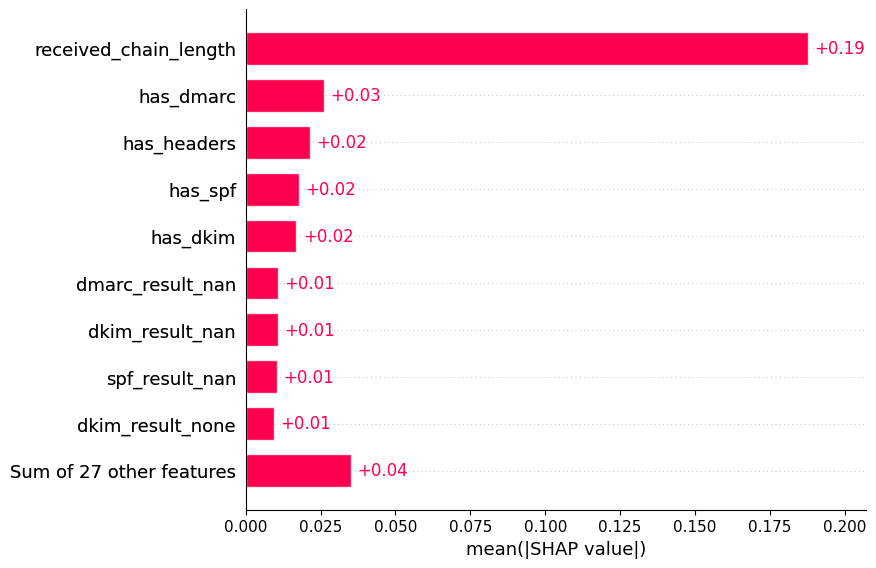

In [ ]:
import matplotlib.pyplot as plt
# explainer = shap.Explainer(predict_meta, train_meta.values)
explainer = shap.Explainer(
    predict_meta,
    train_meta.values,
    feature_names=train_meta.columns.tolist()
)

# shap_values = explainer(train_meta.values)
shap_values = explainer(train_meta.sample(200).values)

# SHAP values for class 0
shap_values_class0 = shap_values[:, :, 0]

# Plot
shap.plots.bar(shap_values_class0)

# pred_class = np.argmax(predict_meta(val_meta.values[:100]), axis=1)

# shap_values_for_pred = np.array(
#     [shap_values[i, pred_class[i]] for i in range(len(pred_class))]
# )

# shap.plots.bar(
#     shap_values_for_pred,
#     feature_names=train_meta.columns.tolist()
# )

# shap_values = explainer(val_meta.values[:100])
# shap.plots.bar(shap_values)

In [ ]:
shap_values = explainer(val_meta.values[:200])

#get predicted class
probs = predict_meta(val_meta.values[:200])
pred_class = probs.argmax(axis=1)

#get shap values for first sample
i = 0  # sample index
cls = pred_class[i]

sample_shap = shap_values.values[i, :, cls]
feature_names = shap_values.feature_names
sample_features = val_meta.iloc[i]


PermutationExplainer explainer: 201it [01:47,  1.77it/s]                         


In [ ]:
import numpy as np

# Sort by absolute influence
idxs = np.argsort(np.abs(sample_shap))[::-1]

top_k = 5   # number of features to include in explanation
top_idxs = idxs[:top_k]


In [ ]:
def explain_metadata_classification(feature_names, feature_values, shap_values, predicted_label):
    explanation = []
    explanation.append(f"The model classified this email as **{predicted_label}**.")
    explanation.append("The most influential metadata factors were:")

    # Rank by absolute importance
    idxs = np.argsort(np.abs(shap_values))[::-1]

    for idx in idxs[:5]:
        name = feature_names[idx]
        value = feature_values[name]
        shap_val = shap_values[idx]

        direction = "increased" if shap_val > 0 else "decreased"
        strength = abs(shap_val)

        explanation.append(
            f"• **{name} = {value}**, which **{direction}** the model's confidence "
            f"in this class (strength: {strength:.3f})."
        )

    return "\n".join(explanation)


In [ ]:
text = explain_metadata_classification(
    feature_names,
    sample_features,
    sample_shap,
    label_encoder.classes_[cls]
)

print(text)


The model classified this email as **Credential Harvesting**.
The most influential metadata factors were:
• **received_chain_length = 3.8223612308502197**, which **increased** the model's confidence in this class (strength: 0.439).
• **has_dmarc = 1.0**, which **increased** the model's confidence in this class (strength: 0.068).
• **has_headers = 1.0**, which **increased** the model's confidence in this class (strength: 0.049).
• **dkim_result_none = 1.0**, which **increased** the model's confidence in this class (strength: 0.041).
• **dkim_result_nan = 0.0**, which **increased** the model's confidence in this class (strength: 0.034).


In [ ]:
print(len(train_df), len(val_df), len(test_df))
print(train_df['Classification'].value_counts())
print(val_df['Classification'].value_counts())
print(test_df['Classification'].value_counts())

30388 13760 13525
Classification
Benign                   14684
Credential Harvesting     7366
Financial Scams           3264
Synthetic BEC             2939
Spam                      2130
Phishing                     5
Name: count, dtype: int64
Classification
Benign                   13599
Credential Harvesting       70
Financial Scams             34
Synthetic BEC               30
Spam                        26
Phishing                     1
Name: count, dtype: int64
Classification
Benign                   13361
Credential Harvesting       74
Financial Scams             37
Synthetic BEC               31
Spam                        22
Name: count, dtype: int64


In [ ]:
y = 'Classification'
X_train = train_df.drop(columns=[y])
y_train = train_df[y]
X_val = val_df.drop(columns=[y])
y_val = val_df[y]
X_test = test_df.drop(columns=[y])
y_test = test_df[y]

y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)

In [ ]:
# meta_features = [
#     'spf_result', 'dkim_result', 'dmarc_result',
#     'num_received', 'received_chain_length',
#     'has_spf', 'has_dkim', 'has_dmarc',
#     'sender_category'
# ]

# cat_features = ['spf_result', 'dkim_result', 'dmarc_result', 'sender_category']
# num_features = ['num_received', 'received_chain_length', 'has_spf', 'has_dkim', 'has_dmarc']

# column_transformer = ColumnTransformer([
#     ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
#     ('num', StandardScaler(), num_features)
# ])

# meta_data = column_transformer.fit_transform(df_combined[meta_features])
# meta_dim = meta_data.shape[1]


In [ ]:

# train_meta = column_transformer.transform(train_df[meta_features])
# val_meta   = column_transformer.transform(val_df[meta_features])
